In [ ]:
import os, math, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane.qnn import TorchLayer
from sklearn.decomposition import PCA
import torchvision
from torchvision import transforms

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOTAL_SAMPLES = 6000      # small uniform subset across all digits (≈200 per class)
BATCH_SIZE     = 128
EPOCHS         = 10
LR_G           = 2e-3
LR_D           = 2e-3
W_DECAY        = 1e-5
TARGET_VAR     = 0.90     # target cumulative variance for PCA → determines qubits
MIN_K          = 2        # minimum PCs (and qubits per model)
MAX_K          = 6        # cap qubits to keep simulation tractable
USE_WGAN       = True     # switch between BCE-GAN and WGAN
CRITIC_ITERS   = 5        # WGAN critic (D) steps per G step
CLIP_VALUE     = 0.01     # WGAN weight clipping
N_GEN_LAYERS   = 2        # depth (StronglyEntanglingLayers) in G
N_DISC_LAYERS  = 2        # depth (StronglyEntanglingLayers) in D

SAVE_DIR       = "./qgan_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)
GEN_PATH       = os.path.join(SAVE_DIR, "generator_final.pth")

def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = torchvision.datasets.MNIST(
        root="./dataset/",
        train=True,
        transform=torchvision.transforms.ToTensor(),
        download=download
    )
    per_class = n_total // 10
    counts = {d:0 for d in range(10)}
    imgs = []
    labels = []
    for x,y in ds:
        if counts[y] < per_class:
            imgs.append(x.numpy().squeeze())  # (28,28) in [0,1]
            labels.append(y)
            counts[y] += 1
        if sum(counts.values()) >= per_class*10:
            break
    X = np.asarray(imgs, dtype=np.float32)    # [N, 28, 28]
    return X

X = load_uniform_mnist_subset()
N = X.shape[0]
X_flat = X.reshape(N, -1)  # [N,784]

pca_full = PCA().fit(X_flat)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_auto = int(np.searchsorted(cum, TARGET_VAR) + 1)
k = max(MIN_K, min(k_auto, MAX_K))
print(f"[PCA] cumulative variance by components: {cum[:10]}")
print(f"[PCA] Chosen k = {k} PCs to reach ≥ {TARGET_VAR:.2f} variance (bounded to [{MIN_K},{MAX_K}]).")

pca = PCA(n_components=k).fit(X_flat)
Z = pca.transform(X_flat)                    # [N,k], real-valued

# Min–max scale each PC to [0,1] so AngleEmbedding is stable
mins = Z.min(axis=0)
maxs = Z.max(axis=0)
ranges = np.maximum(maxs - mins, 1e-8)
Z_scaled = (Z - mins) / ranges               # [0,1]

def inverse_scale(Z01):
    return Z01 * ranges + mins

def inverse_pca(Z01):
    Z_real = inverse_scale(Z01)
    X_rec = pca.inverse_transform(Z_real)
    return X_rec.reshape(-1, 28, 28)

tensor_data = torch.tensor(Z_scaled, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(tensor_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

def make_gen_qnode(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch")
    def qnode(inputs, weights):                     # <--- was z
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return qnode, {"weights": (n_layers, n_qubits, 3)}

def make_disc_qnode(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch")
    def qnode(inputs, weights):                     # <--- was x
        qml.AngleEmbedding(inputs * math.pi, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return qml.expval(qml.PauliZ(0))

    return qnode, {"weights": (n_layers, n_qubits, 3)}

class QGenerator(nn.Module):
    def __init__(self, k, n_layers):
        super().__init__()
        qnode, wsh = make_gen_qnode(k, n_layers)
        self.layer = TorchLayer(qnode, wsh)
    def forward(self, z):                  # z: [B,k] in [0,1]
        out = self.layer(z)                # [-1,1]
        return 0.5*(out + 1.0)             # map → [0,1]

class QDiscriminator(nn.Module):
    def __init__(self, k, n_layers, use_wgan=True):
        super().__init__()
        self.use_wgan = use_wgan
        qnode, wsh = make_disc_qnode(k, n_layers)
        self.layer = TorchLayer(qnode, wsh)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):                  # x: [B,k] in [0,1]
        v = self.layer(x)                  # [-1,1]
        if self.use_wgan:
            return v                       # critic score (unbounded-ish in [-1,1])
        else:
            return self.sigmoid((v+1)/2)   # probability for BCE

G = QGenerator(k, N_GEN_LAYERS).to(device)
D = QDiscriminator(k, N_DISC_LAYERS, use_wgan=USE_WGAN).to(device)

optG = optim.Adam(G.parameters(), lr=LR_G, weight_decay=W_DECAY, betas=(0.5, 0.9))
optD = optim.Adam(D.parameters(), lr=LR_D, weight_decay=W_DECAY, betas=(0.5, 0.9))
bce  = nn.BCELoss()

def sample_z(batch_size, k):
    # latent noise ~ U(0,1)
    return torch.rand((batch_size, k), device=device)

def params_changed(module, old_state):
    for (k1, v1), (k2, v2) in zip(module.state_dict().items(), old_state.items()):
        if not torch.allclose(v1, v2):
            return True
    return False

def clip_disc_weights():
    for p in D.parameters():
        p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

step = 0
for epoch in range(1, EPOCHS+1):
    for (real_batch,) in train_loader:
        real = real_batch.to(device)  # [B,k] in [0,1]

        d_steps = CRITIC_ITERS if USE_WGAN else 1
        for _ in range(d_steps):
            z = sample_z(real.size(0), k)
            fake = G(z).detach()
            D.train(); G.train()

            optD.zero_grad()
            if USE_WGAN:
                d_real = D(real)
                d_fake = D(fake)
                d_loss = -(torch.mean(d_real) - torch.mean(d_fake))
                d_loss.backward()
                optD.step()
                clip_disc_weights()
            else:
                ones  = torch.ones((real.size(0),1), device=device)
                zeros = torch.zeros((real.size(0),1), device=device)
                d_real = D(real)
                d_fake = D(fake)
                d_loss = bce(d_real, ones) + bce(d_fake, zeros)
                d_loss.backward()
                optD.step()

        if step % 100 == 0:
            oldD = {k:v.clone() for k,v in D.state_dict().items()}

        z = sample_z(real.size(0), k)
        optG.zero_grad()
        fake = G(z)
        d_fake = D(fake)
        if USE_WGAN:
            g_loss = -torch.mean(d_fake)
        else:
            ones = torch.ones((real.size(0),1), device=device)
            g_loss = bce(d_fake, ones)
        g_loss.backward()
        optG.step()

        if step % 100 == 0:
            d_updated = params_changed(D, oldD)
            print(f"[epoch {epoch:02d} | step {step:05d}] "
                  f"D_loss={d_loss.item():.4f} G_loss={g_loss.item():.4f} "
                  f"(D updated: {d_updated})")
        step += 1

    with torch.no_grad():
        G.eval()
        z = torch.rand((16, k), device=device)
        gen_features = G(z).detach().cpu().numpy()  # [16,k] in [0,1]
        imgs = inverse_pca(gen_features)
        plt.figure(figsize=(5,5))
        for i in range(16):
            plt.subplot(4,4,i+1)
            plt.imshow(np.clip(imgs[i],0,1), cmap="gray")
            plt.axis("off")
        plt.suptitle(f"Epoch {epoch} generated samples (k={k})")
        plt.tight_layout()
        out_path = os.path.join(SAVE_DIR, f"epoch_{epoch:02d}_samples.png")
        plt.savefig(out_path, dpi=150)
        plt.close()

torch.save(G.state_dict(), GEN_PATH)

G_loaded = QGenerator(k, N_GEN_LAYERS).to(device)
G_loaded.load_state_dict(torch.load(GEN_PATH, map_location=device))
same = all(torch.allclose(a, b) for a,b in zip(G.state_dict().values(),
                                              G_loaded.state_dict().values()))
print(f"[CHECK] Loaded generator identical to trained: {same}")


[PCA] cumulative variance by components: [0.09844905 0.16971236 0.23255965 0.28759146 0.33583143 0.3798141
 0.41274926 0.4423232  0.46962196 0.49296945]
[PCA] Chosen k = 6 PCs to reach ≥ 0.90 variance (bounded to [2,6]).
[epoch 01 | step 00000] D_loss=0.0253 G_loss=0.0004 (D updated: False)
[epoch 03 | step 00100] D_loss=0.0411 G_loss=-0.0069 (D updated: False)
[epoch 05 | step 00200] D_loss=0.0309 G_loss=-0.0303 (D updated: False)
[epoch 07 | step 00300] D_loss=0.0834 G_loss=-0.0635 (D updated: False)
[epoch 09 | step 00400] D_loss=0.0593 G_loss=-0.0757 (D updated: False)
[CHECK] Loaded generator identical to trained: True


Generator outputs (first 5):
[[0.558  0.4976 0.5198 0.214  0.1733 0.4983]
 [0.7144 0.5008 0.4826 0.6955 0.5395 0.4882]
 [0.3129 0.4926 0.3561 0.4959 0.5638 0.4996]
 [0.7573 0.4986 0.5223 0.4892 0.5074 0.501 ]
 [0.4201 0.5054 0.4515 0.6704 0.4993 0.4966]]


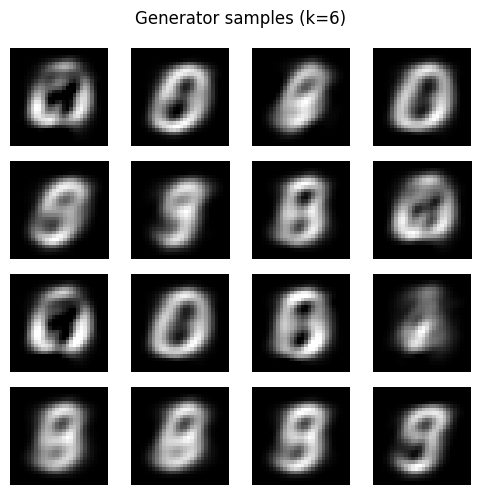

Generator outputs (first 5):
[[0.2433 0.4961 0.357  0.6344 0.5587 0.5127]
 [0.4957 0.4914 0.4467 0.5934 0.6423 0.5081]
 [0.307  0.5001 0.3845 0.5013 0.5068 0.5085]
 [0.4888 0.4996 0.4905 0.533  0.1895 0.4995]
 [0.5796 0.4953 0.5708 0.5208 0.3733 0.5076]]


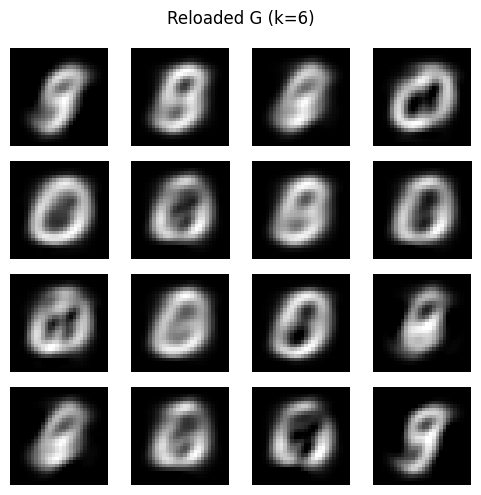

In [ ]:
import os, numpy as np, torch, matplotlib.pyplot as plt

@torch.no_grad()
def sample_and_show(G, k, n=16, save_path=None, title="Generator samples"):
    G.eval()
    # latent in [0,1]
    z = torch.rand((n, k), device=device)
    feats = G(z).detach().cpu().numpy()     # shape [n, k], each in [0,1]
    
    print("Generator outputs (first 5):")
    print(np.round(feats[:5], 4))

    # back to images via inverse PCA
    imgs = inverse_pca(feats)               # shape [n, 28, 28]

    # plot a 4x4 grid
    rows = cols = int(np.sqrt(n))
    plt.figure(figsize=(5,5))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(np.clip(imgs[i], 0, 1), cmap="gray")
        plt.axis("off")
    plt.suptitle(f"{title} (k={k})")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

    return feats, imgs 
_ = sample_and_show(G, k, n=16, save_path=os.path.join(SAVE_DIR, "epoch_last_samples.png"))

G_loaded = QGenerator(k, N_GEN_LAYERS).to(device)
G_loaded.load_state_dict(torch.load(GEN_PATH, map_location=device))
_ = sample_and_show(G_loaded, k, n=16, title="Reloaded G")


In [4]:
LAMBDA_GP = 10.0

def grad_penalty(fake, real):
    # interpolate between real and fake
    eps = torch.rand((real.size(0), 1), device=real.device)
    eps = eps.expand_as(real)
    xhat = eps * real + (1 - eps) * fake
    xhat.requires_grad_(True)

    # two symmetric passes through D
    d1 = D(xhat, real)         # (B,1)
    d2 = D(fake, xhat)         # (B,1)
    ones = torch.ones_like(d1)

    # gradients w.r.t. xhat for both passes
    g1 = torch.autograd.grad(
        outputs=d1, inputs=xhat,
        grad_outputs=ones, create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    g2 = torch.autograd.grad(
        outputs=d2, inputs=xhat,
        grad_outputs=ones, create_graph=True, retain_graph=True, only_inputs=True
    )[0]

    gp = ((g1.view(g1.size(0), -1).norm(2, dim=1) - 1)**2 +
          (g2.view(g2.size(0), -1).norm(2, dim=1) - 1)**2) * 0.5
    return LAMBDA_GP * gp.mean()


[PCA] Cum var (10): [0.0984 0.1697 0.2326 0.2876 0.3358 0.3798 0.4127 0.4423 0.4696 0.493 ]
[PCA] Using k=6
[epoch 01 | step 00000] D=7.0864 GP=7.0827 G=-0.5177
Generator outputs (first 5): [[0.4088 0.4201 0.4816 0.703  0.4122 0.4683]
 [0.3945 0.3993 0.4719 0.5688 0.2438 0.4809]
 [0.4175 0.579  0.5074 0.4987 0.4647 0.5173]
 [0.5472 0.4036 0.609  0.4765 0.4241 0.4714]
 [0.4608 0.5773 0.5137 0.4087 0.423  0.4743]]


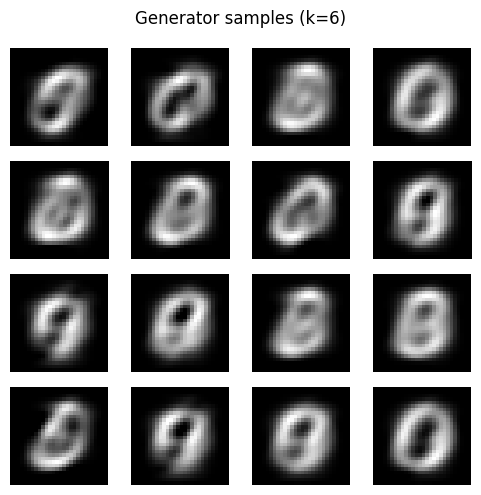

G feature std: [0.08  0.123 0.106 0.084 0.116 0.092]


In [ ]:

def _apply_layer_batched(layer, x):
    if x.dim() == 1:
        return layer(x)
    outs = [layer(xi) for xi in x]
    return torch.stack(outs, dim=0)

# ---------- Repro ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

SAVE_DIR = "./qgan_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)
GEN_PATH = os.path.join(SAVE_DIR, "generator_final.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOTAL_SAMPLES   = 6000
BATCH_SIZE      = 128
EPOCHS          = 10

LR_D, LR_G      = 2e-3, 1e-3
W_DECAY         = 1e-5
BETAS           = (0.5, 0.9)

TARGET_VAR      = 0.90
MIN_K, MAX_K    = 2, 6

USE_WGAN        = True
CRITIC_ITERS    = 5
LAMBDA_GP       = 10.0
NOISE_STD       = 0.02  # instance noise to D inputs

N_GEN_LAYERS    = 3
N_DISC_LAYERS   = 3

ENCODER_G       = "affine"    # "affine" or "prob"
ENCODER_D       = "affine"  # keep affine for stability


def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = torchvision.datasets.MNIST(
        root="./dataset/",
        train=True,
        transform=torchvision.transforms.ToTensor(),
        download=download
    )
    per_class = n_total // 10
    cnt = {d:0 for d in range(10)}
    xs = []
    for x,y in ds:
        if cnt[y] < per_class:
            xs.append(x.numpy().squeeze())
            cnt[y] += 1
        if sum(cnt.values()) >= per_class*10:
            break
    return np.asarray(xs, dtype=np.float32)

X = load_uniform_mnist_subset()
N = X.shape[0]
X_flat = X.reshape(N, -1)

pca_full = PCA().fit(X_flat)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k_auto = int(np.searchsorted(cum, TARGET_VAR) + 1)
k = max(MIN_K, min(k_auto, MAX_K))
print(f"[PCA] Cum var (10): {np.round(cum[:10],4)}")
print(f"[PCA] Using k={k}")

pca = PCA(n_components=k).fit(X_flat)
Z = pca.transform(X_flat)
mins = Z.min(axis=0); maxs = Z.max(axis=0)
ranges = np.maximum(maxs - mins, 1e-8)
Z01 = (Z - mins) / ranges

def inverse_pca(Z01_batch):
    Z_real = Z01_batch * ranges + mins
    X_rec = pca.inverse_transform(Z_real)
    return X_rec.reshape(-1, 28, 28)

tensor_data = torch.tensor(Z01, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(tensor_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

def make_gen_qnode(k, n_layers, encoder="affine"):
    dev = qml.device("default.qubit", wires=k)

    if encoder == "affine":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, enc_w, W1, E1):
            scales, shifts = enc_w[0], enc_w[1]   # (k,)
            angles = scales * inputs + shifts
            for L in range(n_layers):
                # re-upload data
                for i in range(k):
                    qml.RY(angles[i], wires=i)
                # trainable block
                for i in range(k):
                    qml.RX(W1[L, i, 0], wires=i)
                    qml.RY(W1[L, i, 1], wires=i)
                    qml.RZ(W1[L, i, 2], wires=i)
                for i in range(k):
                    qml.IsingXX(E1[L, i], wires=[i, (i+1) % k])
            return [qml.expval(qml.PauliZ(i)) for i in range(k)]
        weight_shapes = {"enc_w": (2, k), "W1": (n_layers, k, 3), "E1": (n_layers, k)}
        return qnode, weight_shapes, None

    elif encoder == "prob":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, tau, W1, E1):
            eps = 1e-6
            tau_pos = 0.1 + 4.9 * qml.math.sigmoid(tau)  # (k,)
            x = qml.math.clip(inputs, eps, 1.0 - eps)
            x_pow = qml.math.pow(x, tau_pos)
            x_pow = qml.math.clip(x_pow, eps, 1.0 - eps)
            angles = 2.0 * qml.math.arcsin(qml.math.sqrt(x_pow))
            for L in range(n_layers):
                for i in range(k):
                    qml.RY(angles[i], wires=i)
                for i in range(k):
                    qml.RX(W1[L, i, 0], wires=i)
                    qml.RY(W1[L, i, 1], wires=i)
                    qml.RZ(W1[L, i, 2], wires=i)
                for i in range(k):
                    qml.IsingXX(E1[L, i], wires=[i, (i+1) % k])
            return [qml.expval(qml.PauliZ(i)) for i in range(k)]
        weight_shapes = {"tau": (k,), "W1": (n_layers, k, 3), "E1": (n_layers, k)}
        return qnode, weight_shapes, None

    else:
        raise ValueError("encoder must be 'affine' or 'prob'")

class QGenerator(nn.Module):
    def __init__(self, k, n_layers, encoder="affine"):
        super().__init__()
        qnode, wsh, _ = make_gen_qnode(k, n_layers, encoder=encoder)
        self.layer = TorchLayer(qnode, wsh)
        self.encoder = encoder
    def forward(self, z):
        raw = _apply_layer_batched(self.layer, z)
        return 0.5 * (raw + 1.0)

def make_eqgan_disc_qnode(k, n_layers, encoder="affine"):
    dev = qml.device("default.qubit", wires=1 + 2*k)

    if encoder == "affine":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, enc_w, Wg, Eg, Wr, Er, theta_swap):
            a = 0; wg = list(range(1, 1+k)); wr = list(range(1+k, 1+2*k))
            scales, shifts = enc_w[0], enc_w[1]  # (2k,)
            ang = scales * inputs + shifts
            ang_g, ang_r = ang[:k], ang[k:]

            for L in range(n_layers):
                # re-upload
                for i in range(k):
                    qml.RY(ang_g[i], wires=wg[i])
                for i in range(k):
                    qml.RY(ang_r[i], wires=wr[i])
                # VQC
                for i in range(k):
                    qml.RX(Wg[L, i, 0], wires=wg[i])
                    qml.RY(Wg[L, i, 1], wires=wg[i])
                    qml.RZ(Wg[L, i, 2], wires=wg[i])
                for i in range(k):
                    qml.IsingXX(Eg[L, i], wires=[wg[i], wg[(i+1) % k]])
                for i in range(k):
                    qml.RX(Wr[L, i, 0], wires=wr[i])
                    qml.RY(Wr[L, i, 1], wires=wr[i])
                    qml.RZ(Wr[L, i, 2], wires=wr[i])
                for i in range(k):
                    qml.IsingXX(Er[L, i], wires=[wr[i], wr[(i+1) % k]])

            qml.RY(theta_swap, wires=a)
            for i in range(k):
                qml.CSWAP(wires=[a, wg[i], wr[i]])
            qml.RY(-theta_swap, wires=a)
            return qml.expval(qml.PauliZ(a))

        weight_shapes = {
            "enc_w": (2, 2*k),
            "Wg": (n_layers, k, 3), "Eg": (n_layers, k),
            "Wr": (n_layers, k, 3), "Er": (n_layers, k),
            "theta_swap": 1
        }
        return qnode, weight_shapes

    elif encoder == "prob":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, tau, Wg, Eg, Wr, Er, theta_swap):
            a = 0; wg = list(range(1, 1+k)); wr = list(range(1+k, 1+2*k))
            eps = 1e-6
            tau_pos = 0.1 + 4.9 * qml.math.sigmoid(tau)  # (2k,)
            x = qml.math.clip(inputs, eps, 1.0 - eps)
            x_pow = qml.math.pow(x, tau_pos)
            x_pow = qml.math.clip(x_pow, eps, 1.0 - eps)
            ang = 2.0 * qml.math.arcsin(qml.math.sqrt(x_pow))
            ang_g, ang_r = ang[:k], ang[k:]

            for L in range(n_layers):
                for i in range(k):
                    qml.RY(ang_g[i], wires=wg[i])
                for i in range(k):
                    qml.RY(ang_r[i], wires=wr[i])
                for i in range(k):
                    qml.RX(Wg[L, i, 0], wires=wg[i])
                    qml.RY(Wg[L, i, 1], wires=wg[i])
                    qml.RZ(Wg[L, i, 2], wires=wg[i])
                for i in range(k):
                    qml.IsingXX(Eg[L, i], wires=[wg[i], wg[(i+1) % k]])
                for i in range(k):
                    qml.RX(Wr[L, i, 0], wires=wr[i])
                    qml.RY(Wr[L, i, 1], wires=wr[i])
                    qml.RZ(Wr[L, i, 2], wires=wr[i])
                for i in range(k):
                    qml.IsingXX(Er[L, i], wires=[wr[i], wr[(i+1) % k]])

            qml.RY(theta_swap, wires=a)
            for i in range(k):
                qml.CSWAP(wires=[a, wg[i], wr[i]])
            qml.RY(-theta_swap, wires=a)
            return qml.expval(qml.PauliZ(a))

        weight_shapes = {
            "tau": (2*k,),
            "Wg": (n_layers, k, 3), "Eg": (n_layers, k),
            "Wr": (n_layers, k, 3), "Er": (n_layers, k),
            "theta_swap": 1
        }
        return qnode, weight_shapes

    else:
        raise ValueError("encoder must be 'affine' or 'prob'")

class QDiscriminatorEQGAN(nn.Module):
    def __init__(self, k, n_layers, use_wgan=True, encoder="affine"):
        super().__init__()
        qnode, wsh = make_eqgan_disc_qnode(k, n_layers, encoder=encoder)
        self.layer = TorchLayer(qnode, wsh)
        self.use_wgan = use_wgan
    def forward(self, x1, x2):
        inputs = torch.cat([x1, x2], dim=-1)
        raw = _apply_layer_batched(self.layer, inputs)
        if raw.dim() == 0: raw = raw.unsqueeze(0)
        raw = raw.view(-1, 1)
        return raw if self.use_wgan else torch.sigmoid((raw + 1.0)/2.0)

G = QGenerator(k, N_GEN_LAYERS, encoder=ENCODER_G).to(device)
D = QDiscriminatorEQGAN(k, N_DISC_LAYERS, use_wgan=USE_WGAN, encoder=ENCODER_D).to(device)

optG = optim.Adam(G.parameters(), lr=LR_G, weight_decay=W_DECAY, betas=BETAS)
optD = optim.Adam(D.parameters(), lr=LR_D, weight_decay=W_DECAY, betas=BETAS)
bce  = nn.BCELoss()

# encoder inits
if ENCODER_G == "prob":
    with torch.no_grad():
        for n, p in G.layer.named_parameters():
            if n.endswith("tau"):   # tau_pos ≈ 1.0  → tau ≈ -1.49
                p.fill_(-1.49)
if ENCODER_D == "affine":
    with torch.no_grad():
        for n, p in D.layer.named_parameters():
            if n.endswith("enc_w"):   # (2, 2k): scales; shifts
                p.zero_(); p[0].fill_(math.pi); p[1].fill_(0.0)
            if n.endswith("theta_swap"):
                p.fill_(math.pi/4)

def sample_z(batch, k):
    return torch.rand((batch, k), device=device)

def grad_penalty(fake, real):
    # interpolate
    eps = torch.rand((real.size(0), 1), device=real.device).expand_as(real)
    xhat = eps * real + (1 - eps) * fake
    xhat.requires_grad_(True)

    d1 = D(xhat, real)
    d2 = D(fake, xhat)
    ones = torch.ones_like(d1)

    g1 = torch.autograd.grad(d1, xhat, ones, create_graph=True, retain_graph=True, only_inputs=True)[0]
    g2 = torch.autograd.grad(d2, xhat, ones, create_graph=True, retain_graph=True, only_inputs=True)[0]

    gp = ((g1.view(g1.size(0), -1).norm(2, dim=1) - 1)**2 +
          (g2.view(g2.size(0), -1).norm(2, dim=1) - 1)**2) * 0.5
    return LAMBDA_GP * gp.mean()

@torch.no_grad()
def sample_and_show(G, k, n=16, title="Generator samples", save_path=None):
    G.eval()
    z = torch.rand((n, k), device=device)
    feats = G(z).detach().cpu().numpy()
    print("Generator outputs (first 5):", np.round(feats[:5], 4))
    imgs = inverse_pca(feats)
    r = c = int(np.sqrt(n))
    plt.figure(figsize=(5,5))
    for i in range(n):
        plt.subplot(r, c, i+1); plt.imshow(np.clip(imgs[i],0,1), cmap="gray"); plt.axis("off")
    plt.suptitle(f"{title} (k={k})"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    return feats, imgs

step = 0
for epoch in range(1, EPOCHS+1):
    for (real_batch,) in train_loader:
        real = real_batch.to(device)

        for _ in range(CRITIC_ITERS if USE_WGAN else 1):
            z = sample_z(real.size(0), k)
            fake = G(z).detach()
            # instance noise
            real_n = (real + NOISE_STD*torch.randn_like(real)).clamp(0,1)
            fake_n = (fake + NOISE_STD*torch.randn_like(fake)).clamp(0,1)

            optD.zero_grad()
            if USE_WGAN:
                d_real = D(real_n, fake_n)
                d_fake = D(fake_n, real_n)
                wasserstein = torch.mean(d_real) - torch.mean(d_fake)
                gp = grad_penalty(fake_n, real_n)
                d_loss = -(wasserstein) + gp
            else:
                ones  = torch.ones((real.size(0),1), device=device)
                zeros = torch.zeros((real.size(0),1), device=device)
                d_loss = bce(D(real_n, fake_n), ones) + bce(D(fake_n, real_n), zeros)
            d_loss.backward()
            optD.step()

        z = sample_z(real.size(0), k)
        fake = G(z)
        real_n = (real + NOISE_STD*torch.randn_like(real)).clamp(0,1)
        fake_n = (fake + NOISE_STD*torch.randn_like(fake)).clamp(0,1)
        optG.zero_grad()
        if USE_WGAN:
            g_loss = -torch.mean(D(fake_n, real_n))
        else:
            ones = torch.ones((real.size(0),1), device=device)
            g_loss = bce(D(fake_n, real_n), ones)
        g_loss.backward()
        optG.step()

        if step % 100 == 0:
            if USE_WGAN:
                print(f"[epoch {epoch:02d} | step {step:05d}] D={d_loss.item():.4f} GP={gp.item():.4f} G={g_loss.item():.4f}")
            else:
                print(f"[epoch {epoch:02d} | step {step:05d}] D={d_loss.item():.4f} G={g_loss.item():.4f}")
        step += 1

    _ = sample_and_show(G, k, n=16, save_path=os.path.join(SAVE_DIR, f"epoch_{epoch:02d}_samples.png"))
    with torch.no_grad():
        z_cov = torch.rand((512, k), device=device)
        gfeat = G(z_cov).cpu().numpy()
        print("G feature std:", np.round(gfeat.std(axis=0), 3))

torch.save(G.state_dict(), GEN_PATH)
G_loaded = QGenerator(k, N_GEN_LAYERS, encoder=ENCODER_G).to(device)
G_loaded.load_state_dict(torch.load(GEN_PATH, map_location=device))
same = all(torch.allclose(a, b) for a,b in zip(G.state_dict().values(), G_loaded.state_dict().values()))
print(f"[CHECK] Loaded generator identical to trained: {same}")


In [ ]:

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

USE_CLASSICAL_CRITIC = True
TRY_LIGHTNING        = True
device = torch.device("cpu")

TOTAL_SAMPLES = 5000
BATCH_SIZE    = 128
EPOCHS        = 12

LATENT  = 48
K_FEAT  = 16
KQ      = K_FEAT // 2
assert 2*KQ == K_FEAT

LR_D, LR_G = 1e-5, 3e-4
BETAS      = (0.5, 0.999)
W_DECAY    = 1e-5
D_UPDATES  = 1
G_UPDATES  = 3

NOISE_STD = 0.10

N_GEN_LAYERS  = 2
N_DISC_LAYERS = 2

SAVE_DIR = "./mnist_eqgan_clip_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)
GEN_PATH = os.path.join(SAVE_DIR, "generator_final.pth")

W_FM  = 0.10
W_COV = 0.05
W_SWD = 0.02
W_TV  = 0.005

USE_ANGLE_L2        = True
ANGLE_L2_WEIGHT_G   = 2e-4
USE_GRAD_CLIP       = True
GRAD_CLIP_D         = 0.5
GRAD_CLIP_G         = 1.0
USE_EMA_G           = True
EMA_DECAY           = 0.999
GP_WEIGHT   = 100.0
DRIFT_EPS   = 1e-3

def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = torchvision.datasets.MNIST(
        root="./dataset/",
        train=True,
        transform=transforms.ToTensor(),
        download=download
    )
    per_class = max(1, n_total // 10)
    cnt = {d: 0 for d in range(10)}
    xs = []
    for x, y in ds:
        if cnt[y] < per_class:
            xs.append(x.numpy().squeeze())
            cnt[y] += 1
        if sum(cnt.values()) >= per_class * 10:
            break
    return np.asarray(xs, dtype=np.float32)

X = load_uniform_mnist_subset()
N, H, W = X.shape
X_flat  = X.reshape(N, -1)

pca = PCA(n_components=K_FEAT).fit(X_flat)
Z   = pca.transform(X_flat)
mu   = Z.mean(axis=0)
std  = Z.std(axis=0) + 1e-6
Zz   = (Z - mu) / std

def inverse_pca(Zz_batch):
    if isinstance(Zz_batch, torch.Tensor):
        Zz_batch = Zz_batch.detach().cpu().numpy()
    Z_real = Zz_batch * std + mu
    return pca.inverse_transform(Z_real).reshape(-1, H, W)

tensor_data = torch.tensor(Zz, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(tensor_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

def _get_dev(wires):
    if TRY_LIGHTNING:
        try:
            dev = qml.device("lightning.qubit", wires=wires)
            return dev, "adjoint"
        except Exception:
            pass
    return qml.device("default.qubit", wires=wires), "backprop"

def make_gen_qnode(kq, n_layers):
    dev, diff = _get_dev(kq)
    @qml.qnode(dev, interface="torch", diff_method=diff)
    def qnode(inputs, enc_w, W1, E1):
        scales, shifts = enc_w[0], enc_w[1]
        angles = scales * inputs + shifts
        for L in range(n_layers):
            for i in range(kq): qml.RY(angles[i], wires=i)
            for i in range(kq):
                qml.RX(W1[L,i,0], wires=i)
                qml.RY(W1[L,i,1], wires=i)
                qml.RZ(W1[L,i,2], wires=i)
            for i in range(kq): qml.IsingXX(E1[L,i], wires=[i,(i+1)%kq])
        outs = [qml.expval(qml.PauliZ(i)) for i in range(kq)]
        outs += [qml.expval(qml.PauliX(i)) for i in range(kq)]
        return outs
    wsh = {"enc_w": (2, kq), "W1": (n_layers, kq, 3), "E1": (n_layers, kq)}
    return qnode, wsh

class QGenerator(nn.Module):
    def __init__(self, kq, n_layers):
        super().__init__()
        qnode, wsh = make_gen_qnode(kq, n_layers)
        self.layer = TorchLayer(qnode, wsh)
        self.noise_to_inputs = nn.Sequential(
            nn.Linear(LATENT, 96), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(96, kq), nn.Tanh()
        )
        with torch.no_grad():
            for n, p in self.layer.named_parameters():
                if n.endswith("enc_w"):
                    p.zero_(); p[0].fill_(math.pi/4); p[1].fill_(0.0)
    def forward(self, z):
        z01 = 0.5 * (self.noise_to_inputs(z) + 1.0)
        return torch.stack([self.layer(xi) for xi in z01], dim=0)

class MLPDiscriminator(nn.Module):
    def __init__(self, kfeat):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2*kfeat, 64), nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 64), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, 1)
        )
    def forward(self, real_feats, fake_feats):
        x = torch.cat([fake_feats, real_feats], dim=-1)
        return self.net(x)

G = QGenerator(KQ, N_GEN_LAYERS)
D = MLPDiscriminator(K_FEAT)

optG = optim.Adam(G.parameters(), lr=LR_G, weight_decay=W_DECAY, betas=BETAS)
optD = optim.Adam(D.parameters(), lr=LR_D, weight_decay=W_DECAY, betas=BETAS)

for m in D.net.modules():
    if isinstance(m, nn.Linear):
        nn.utils.parametrizations.spectral_norm(m)

def sample_z(batch): return torch.randn((batch, LATENT))

def cov(mat):
    X = mat - mat.mean(0, keepdim=True)
    return (X.T @ X) / (X.size(0)-1)

def sliced_wasserstein(x, y, n_proj=32):
    B,D = x.shape
    v = torch.randn(D, n_proj, device=x.device); v = v/v.norm(dim=0)
    xs,_ = torch.sort(x@v,dim=0); ys,_ = torch.sort(y@v,dim=0)
    return (xs-ys).pow(2).mean()

def tv_from_feats(feats, max_b=48):
    with torch.no_grad(): imgs_np = inverse_pca(feats[:max_b])
    imgs_t = torch.tensor(imgs_np, dtype=torch.float32, device=feats.device).unsqueeze(1)
    dx = imgs_t[:,:,:,1:] - imgs_t[:,:,:,:-1]
    dy = imgs_t[:,:,1:,:] - imgs_t[:,:,:-1,:]
    return dx.abs().mean()+dy.abs().mean()

class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k:v.clone() for k,v in model.state_dict().items()}
    def update(self, model):
        for k,v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
    def copy_to(self, model): model.load_state_dict(self.shadow)

ema = EMA(G, decay=EMA_DECAY) if USE_EMA_G else None

=step=0
for epoch in range(1,EPOCHS+1):
    for (real_batch,) in train_loader:
        real=real_batch
        # --- D ---
        z=sample_z(real.size(0)); fake=G(z).detach()
        real_n=real+NOISE_STD*torch.randn_like(real)
        fake_n=fake+NOISE_STD*torch.randn_like(fake)

        optD.zero_grad()
        d_real=D(real_n,fake_n).squeeze()
        d_fake=D(fake_n,real_n).squeeze()
        d_loss=-(d_real.mean()-d_fake.mean())
        d_loss+=DRIFT_EPS*(d_real.pow(2).mean()+d_fake.pow(2).mean())

        eps=torch.rand(real_n.size(0),1,device=real.device)
        xa=eps*real_n+(1-eps)*fake_n; xb=(1-eps)*real_n+eps*fake_n
        xa.requires_grad_(True); xb.requires_grad_(True)
        scores=D(xa,xb).sum()
        grad_xa,grad_xb=torch.autograd.grad(scores,[xa,xb],create_graph=True)
        grad_pair=torch.cat([grad_xa,grad_xb],dim=-1)
        gp=(grad_pair.view(grad_pair.size(0),-1).norm(2,dim=1)-1).pow(2).mean()
        d_loss+=GP_WEIGHT*gp

        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(),GRAD_CLIP_D)
        optD.step()
        for p in D.parameters(): p.data.clamp_(-0.5,0.5)
        for _ in range(G_UPDATES):
            z=sample_z(real.size(0)); fake=G(z)
            optG.zero_grad()
            g_adv=-D(fake,real).mean()
            with torch.no_grad(): mu_r=real.mean(0); sd_r=real.std(0)
            mu_f=fake.mean(0); sd_f=fake.std(0)
            fm_loss=(mu_f-mu_r).pow(2).mean()+(sd_f-sd_r).pow(2).mean()
            cov_loss=(cov(fake)-cov(real.detach())).pow(2).mean()
            swd_loss=sliced_wasserstein(fake,real.detach())
            tv=tv_from_feats(fake)
            g_loss=g_adv+W_FM*fm_loss+W_COV*cov_loss+W_SWD*swd_loss+W_TV*tv
            if USE_ANGLE_L2: g_loss+=ANGLE_L2_WEIGHT_G*sum((p**2).mean() for n,p in G.named_parameters() if "enc_w" in n or "W1" in n or "E1" in n)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(),GRAD_CLIP_G)
            optG.step()
            if ema: ema.update(G)
        step+=1
    print(f"Epoch {epoch:02d} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f} "
          f"| FM: {fm_loss.item():.4f} | COV: {cov_loss.item():.4f} "
          f"| SWD: {swd_loss.item():.4f} | TV: {tv.item():.4f}")


Epoch 01 | D: 73.7064 | G: 0.2191 | FM: 0.9335 | COV: 0.0674 | SWD: 0.9263 | TV: 0.0675
Epoch 02 | D: 73.3901 | G: 0.1875 | FM: 0.8458 | COV: 0.0694 | SWD: 0.7880 | TV: 0.0670
Epoch 03 | D: 71.9253 | G: 0.1586 | FM: 0.8569 | COV: 0.0731 | SWD: 0.7877 | TV: 0.0688
Epoch 04 | D: 71.0040 | G: 0.1394 | FM: 0.7861 | COV: 0.0626 | SWD: 0.7833 | TV: 0.0698
Epoch 05 | D: 70.9387 | G: 0.1142 | FM: 0.8076 | COV: 0.0631 | SWD: 0.8009 | TV: 0.0713
Epoch 06 | D: 69.9557 | G: 0.0989 | FM: 0.7533 | COV: 0.0671 | SWD: 0.7849 | TV: 0.0732
Epoch 07 | D: 68.0960 | G: 0.0894 | FM: 0.7915 | COV: 0.0639 | SWD: 0.7803 | TV: 0.0759
Epoch 08 | D: 67.1980 | G: 0.0593 | FM: 0.7329 | COV: 0.0621 | SWD: 0.6625 | TV: 0.0770
Epoch 09 | D: 65.2529 | G: 0.0393 | FM: 0.8231 | COV: 0.0648 | SWD: 0.8446 | TV: 0.0787
Epoch 10 | D: 65.0223 | G: 0.0249 | FM: 0.7555 | COV: 0.0575 | SWD: 0.7324 | TV: 0.0799
Epoch 11 | D: 63.2606 | G: 0.0035 | FM: 0.8093 | COV: 0.0664 | SWD: 0.7873 | TV: 0.0810
Epoch 12 | D: 61.9407 | G: -0.00

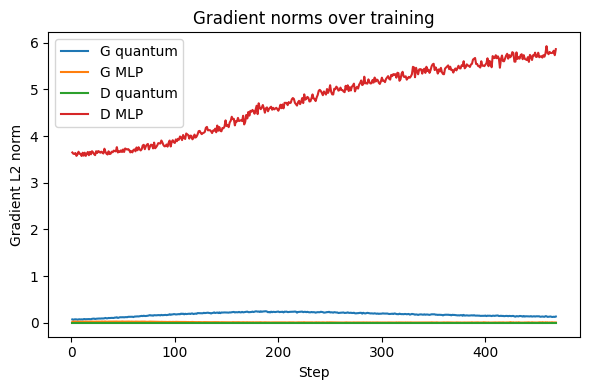

In [ ]:
plt.figure(figsize=(6,4))
s = np.array(grad_log["step"])
def _plot(y, label):
    y = np.array(y)
    if len(y) > 0: plt.plot(s, y, label=label)
_plot(grad_log["G_quant"], "G quantum")
_plot(grad_log["G_mlp"],   "G MLP")
_plot(grad_log["D_quant"], "D quantum")
_plot(grad_log["D_mlp"],   "D MLP")
plt.xlabel("Step"); plt.ylabel("Gradient L2 norm")
plt.title("Gradient norms over training")
plt.legend(); plt.tight_layout(); plt.show()


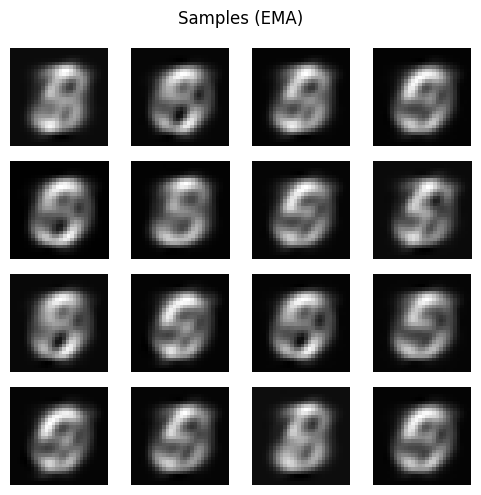

In [9]:
@torch.no_grad()
def sample_and_show(G_model, n=16, title="Generated samples", save_path=None):
    G_model.eval()
    z   = torch.randn((n, LATENT))
    f   = G_model(z).cpu().numpy()       # [n, K_FEAT] PCA features
    imgs= inverse_pca(f)                 # back to [28,28]

    r = c = int(np.sqrt(n))
    plt.figure(figsize=(5,5))
    for i in range(n):
        plt.subplot(r,c,i+1)
        plt.imshow(imgs[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    return imgs

# Use EMA weights if enabled
if USE_EMA_G and ema is not None:
    G_tmp = QGenerator(KQ, N_GEN_LAYERS)
    ema.copy_to(G_tmp)
    _ = sample_and_show(G_tmp, n=16, title="Samples (EMA)")
else:
    _ = sample_and_show(G, n=16, title="Samples (latest G)")


Global summary:
 real | min=0.0000 max=1.0000 mean=0.4867 std=0.1793
 fake | min=0.0622 max=0.9291 mean=0.4963 std=0.1428

Per-component summary (real vs fake):
comp |   real_mean  real_std  |   fake_mean  fake_std
-----+-------------------------+------------------------
   0 |      0.3256    0.1858 |      0.4458    0.1248
   1 |      0.4804    0.1945 |      0.4947    0.1549
   2 |      0.5168    0.1768 |      0.4573    0.1303
   3 |      0.4967    0.1772 |      0.4771    0.1074
   4 |      0.4169    0.1513 |      0.4941    0.1182
   5 |      0.5546    0.1845 |      0.4908    0.0768
   6 |      0.4606    0.1555 |      0.4978    0.1708
   7 |      0.4929    0.1458 |      0.4990    0.1777
   8 |      0.4992    0.1674 |      0.5313    0.1300
   9 |      0.5407    0.1626 |      0.5890    0.0976
  10 |      0.5970    0.1559 |      0.4978    0.1332
  11 |      0.4592    0.1280 |      0.4809    0.1927


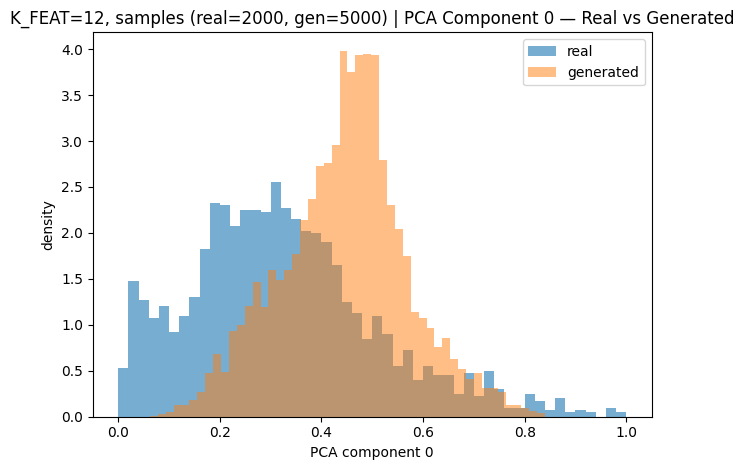

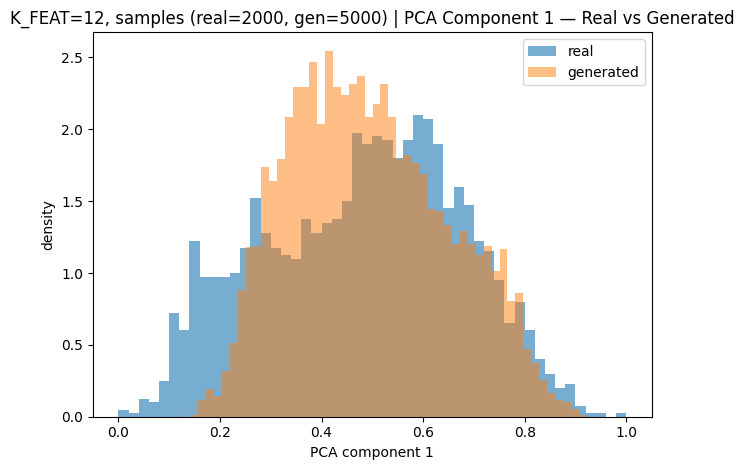

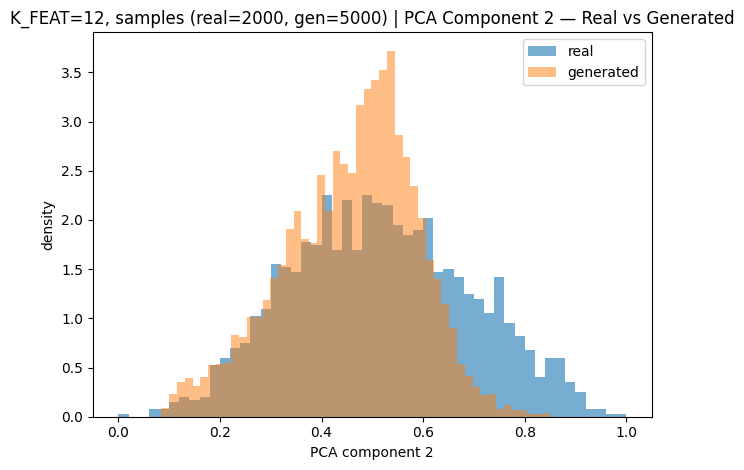

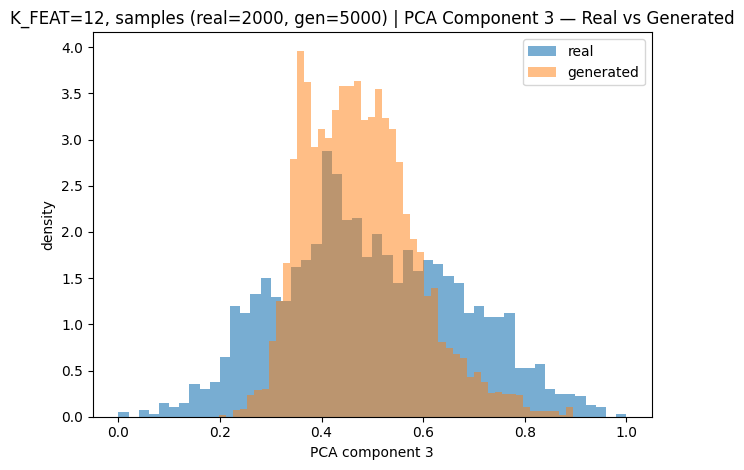

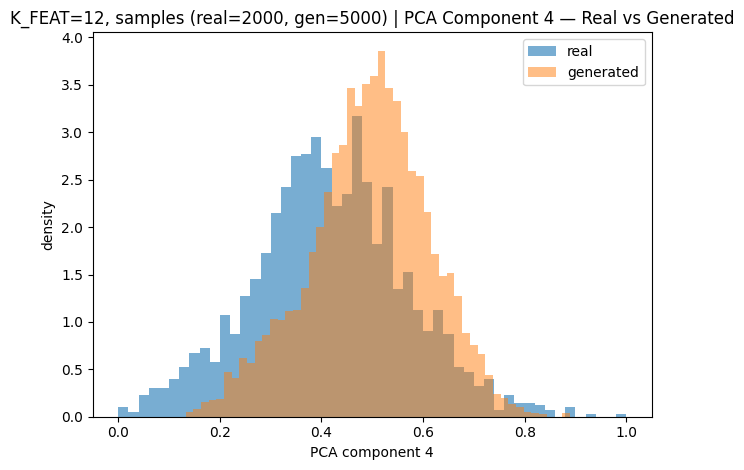

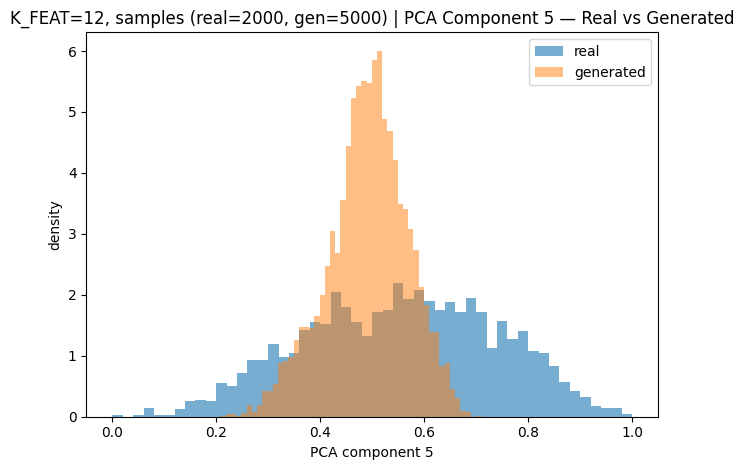

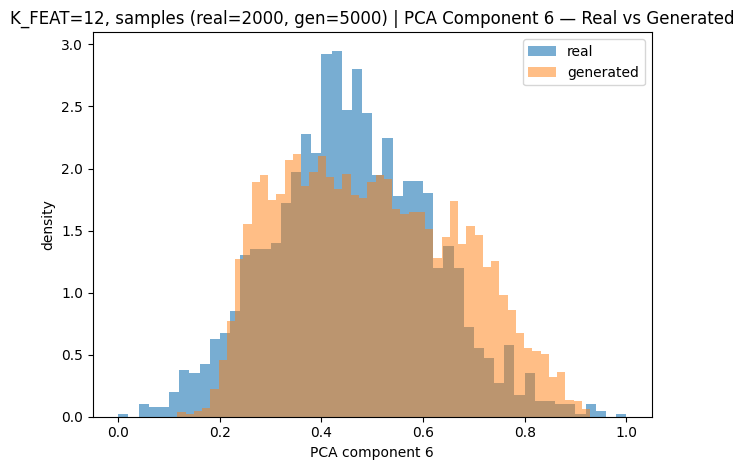

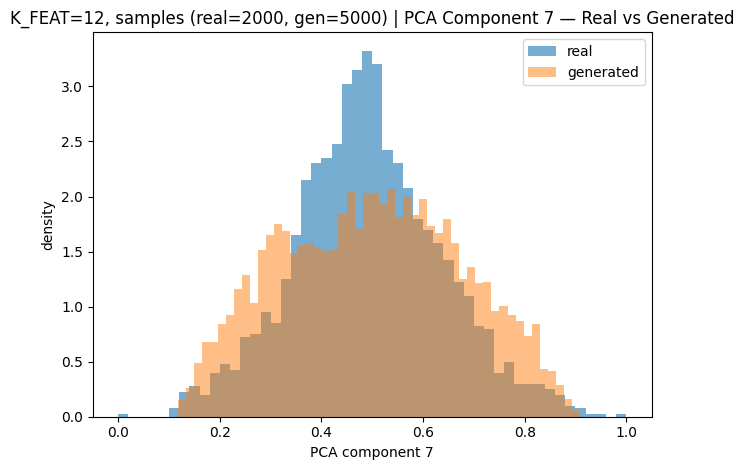

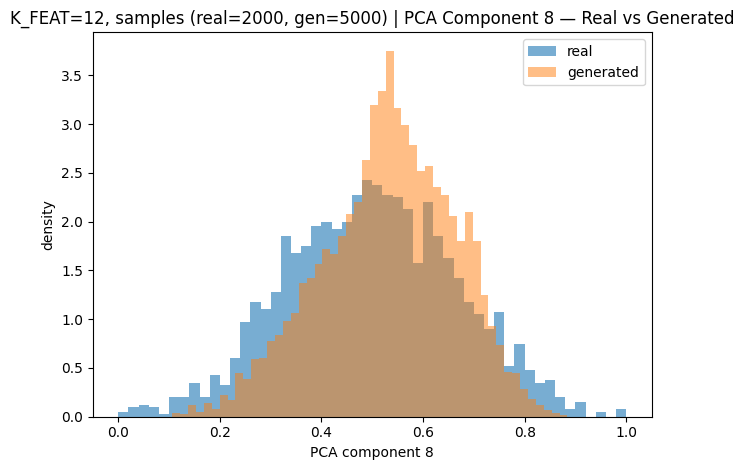

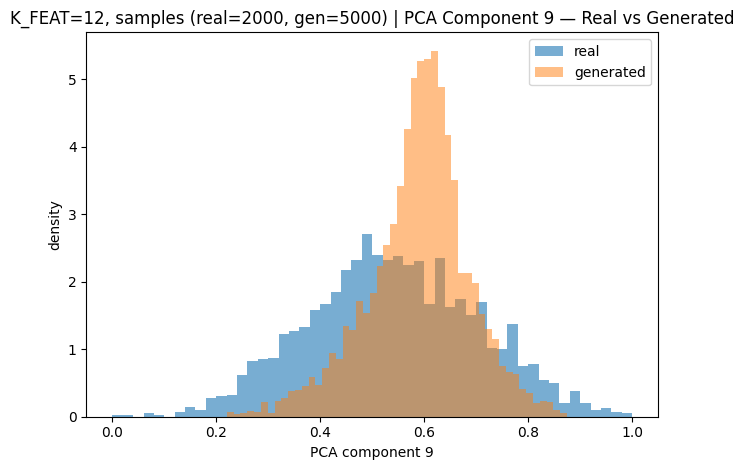

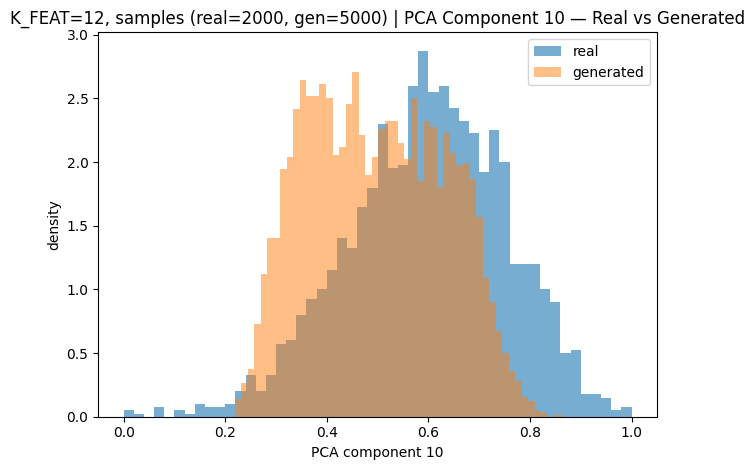

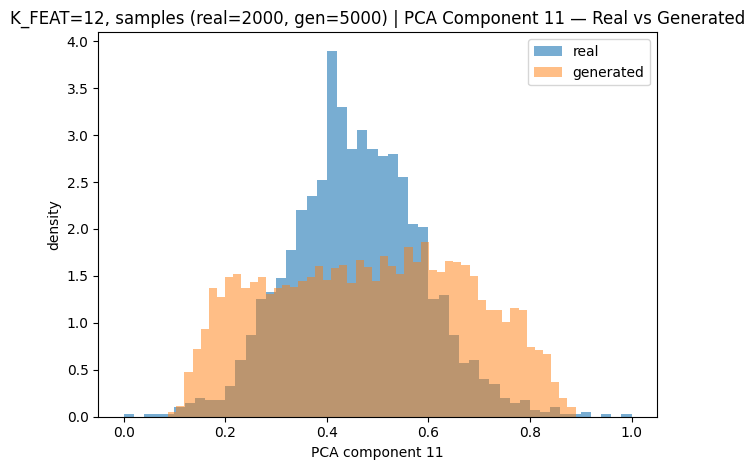

In [ ]:
# ============================
# PCA component histograms: real vs generated
# ============================

import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def gen_features(G, n_samples, KQ):
    G.eval()
    z = torch.rand((n_samples, KQ))
    feats = G(z).cpu().numpy()            # [n_samples, K_FEAT] in [0,1]
    return feats

def summarize(name, arr):
    return {
        "name": name,
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr))
    }

def print_component_stats(real_feats, fake_feats):
    K = real_feats.shape[1]
    print("\nPer-component summary (real vs fake):")
    print("comp |   real_mean  real_std  |   fake_mean  fake_std")
    print("-----+-------------------------+------------------------")
    for k in range(K):
        r_mean, r_std = real_feats[:,k].mean(), real_feats[:,k].std()
        f_mean, f_std = fake_feats[:,k].mean(), fake_feats[:,k].std()
        print(f"{k:>4} |  {r_mean:10.4f}  {r_std:8.4f} |  {f_mean:10.4f}  {f_std:8.4f}")

def plot_pca_histograms(
    real_feats, fake_feats, bins=50, n_show=None, suptitle=None
):
    """
    Plots one histogram per PCA component, overlaying real vs generated.
    NOTE: This will create one figure per component (no subplots) to keep things simple.
    """
    K = real_feats.shape[1]
    if n_show is not None:
        real_feats = real_feats[:n_show]
        fake_feats = fake_feats[:n_show]

    for k in range(K):
        plt.figure()
        # Real
        plt.hist(
            real_feats[:, k],
            bins=bins, density=True, alpha=0.6,
            label="real"
        )
        # Generated
        plt.hist(
            fake_feats[:, k],
            bins=bins, density=True, alpha=0.5,
            label="generated"
        )
        plt.xlabel(f"PCA component {k}")
        plt.ylabel("density")
        title = f"PCA Component {k} — Real vs Generated"
        if suptitle:
            title = suptitle + " | " + title
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

N_GEN_SAMPLES = 5000  # increase for smoother curves
fake_feats = gen_features(G, N_GEN_SAMPLES, KQ)

real_stats = summarize("real", Z01)
fake_stats = summarize("fake", fake_feats)
print("Global summary:")
for d in (real_stats, fake_stats):
    print(f"{d['name']:>5} | min={d['min']:.4f} max={d['max']:.4f} "
          f"mean={d['mean']:.4f} std={d['std']:.4f}")

print_component_stats(Z01, fake_feats)

plot_pca_histograms(
    real_feats=Z01,
    fake_feats=fake_feats,
    bins=50,
    n_show=None,
    suptitle=f"K_FEAT={K_FEAT}, samples (real={len(Z01)}, gen={len(fake_feats)})"
)


In [ ]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from pennylane.qnn import TorchLayer
from sklearn.decomposition import PCA
import torchvision
from torchvision import transforms

Epoch 01 | D: 7.3255 | G: -0.4606 | FM: 0.0308


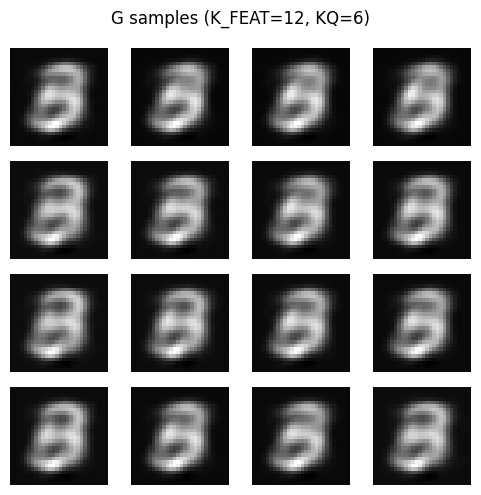

G feature std: [0.028 0.018 0.017 0.014 0.014 0.064 0.014 0.015 0.01  0.015 0.015 0.033]
Epoch 02 | D: 6.1058 | G: -0.4476 | FM: 0.0288


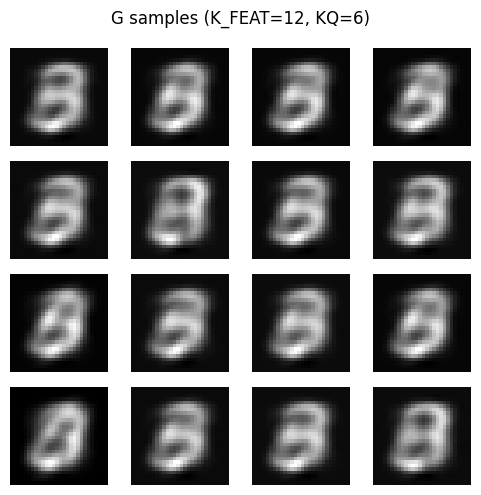

G feature std: [0.033 0.018 0.018 0.014 0.015 0.071 0.016 0.015 0.011 0.017 0.016 0.037]
Epoch 03 | D: 5.5574 | G: -0.4339 | FM: 0.0273


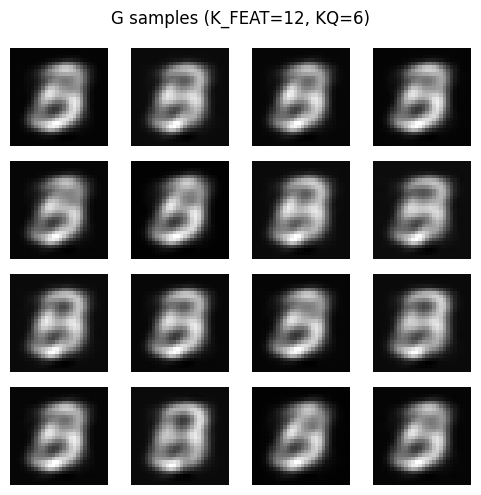

G feature std: [0.033 0.02  0.019 0.016 0.017 0.07  0.021 0.017 0.011 0.017 0.015 0.038]
Epoch 04 | D: 5.0955 | G: -0.4249 | FM: 0.0261


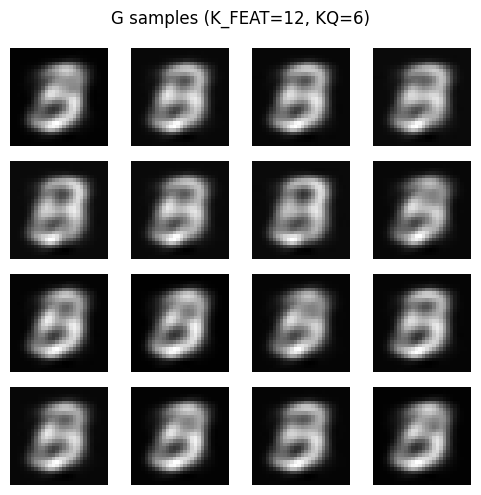

G feature std: [0.034 0.02  0.018 0.018 0.021 0.071 0.023 0.017 0.011 0.018 0.016 0.043]
Epoch 05 | D: 4.7526 | G: -0.4136 | FM: 0.0264


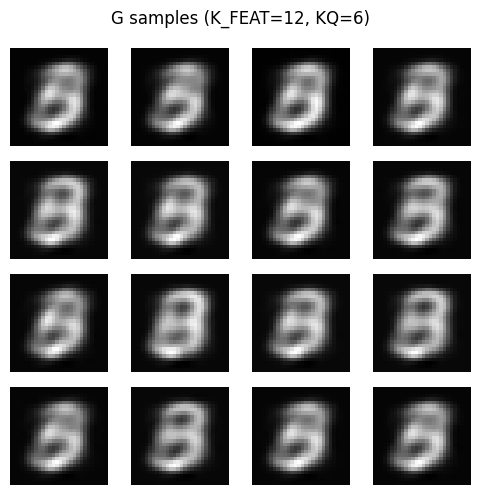

G feature std: [0.035 0.021 0.017 0.019 0.023 0.073 0.026 0.019 0.011 0.018 0.016 0.043]
Epoch 06 | D: 4.7772 | G: -0.4050 | FM: 0.0246


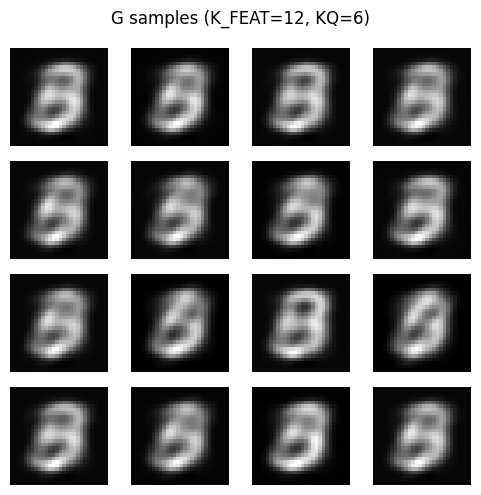

G feature std: [0.036 0.021 0.018 0.019 0.023 0.074 0.029 0.018 0.012 0.019 0.015 0.043]
Epoch 07 | D: 4.2111 | G: -0.3964 | FM: 0.0252


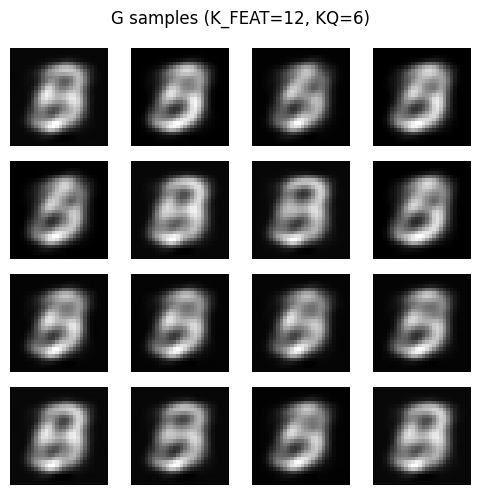

G feature std: [0.038 0.023 0.018 0.021 0.026 0.079 0.033 0.021 0.013 0.02  0.016 0.044]
Epoch 08 | D: 4.6672 | G: -0.3874 | FM: 0.0249


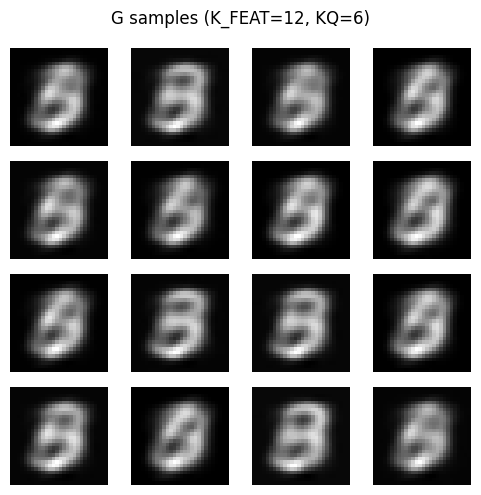

G feature std: [0.036 0.025 0.018 0.022 0.031 0.076 0.036 0.022 0.013 0.021 0.016 0.046]
Epoch 09 | D: 3.8568 | G: -0.3859 | FM: 0.0232


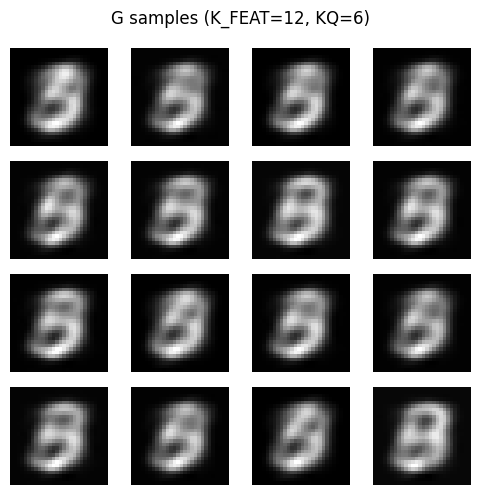

G feature std: [0.036 0.026 0.018 0.023 0.033 0.073 0.039 0.022 0.014 0.02  0.015 0.049]
Epoch 10 | D: 3.6606 | G: -0.3739 | FM: 0.0242


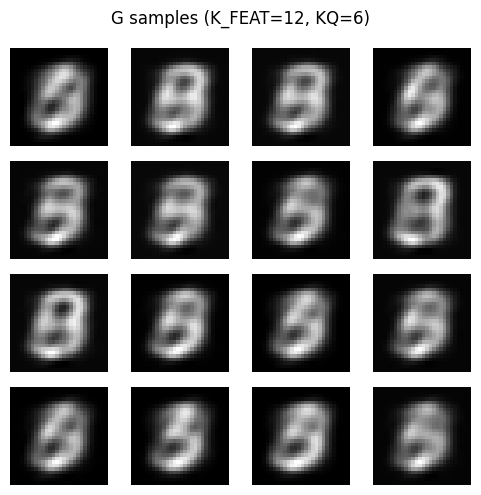

G feature std: [0.033 0.027 0.02  0.025 0.035 0.07  0.043 0.023 0.014 0.021 0.015 0.05 ]


In [ ]:


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cpu")  # PL TorchLayer (default.qubit) runs CPU

TOTAL_SAMPLES = 2000
BATCH_SIZE    = 128
EPOCHS        = 30
LR_D, LR_G    = 2e-4, 1e-4
BETAS         = (0.5, 0.999)
W_DECAY       = 1e-5
K_FEAT = 12                 # must be even
KQ     = K_FEAT // 2
assert 2*KQ == K_FEAT, "K_FEAT must be even"

USE_WGAN     = True
CRITIC_ITERS = 5            # stronger critic
LAMBDA_GP    = 10.0
GP_EVERY     = 1            # GP each step for stability
NOISE_STD    = 0.01

N_GEN_LAYERS  = 6
N_DISC_LAYERS = 6
ENCODER_G = "affine"        # switch G to affine for better variance
ENCODER_D = "affine"

SAVE_DIR = "./mnist_qgan_rxry_ckpts"
os.makedirs(SAVE_DIR, exist_ok=True)
GEN_PATH = os.path.join(SAVE_DIR, "generator_final.pth")

def load_uniform_mnist_subset(n_total=TOTAL_SAMPLES, download=True):
    ds = torchvision.datasets.MNIST(
        root="./dataset/",
        train=True,
        transform=transforms.ToTensor(),
        download=download
    )
    per_class = n_total // 10
    cnt = {d: 0 for d in range(10)}
    xs = []
    for x, y in ds:
        if cnt[y] < per_class:
            xs.append(x.numpy().squeeze())  # (28,28) in [0,1]
            cnt[y] += 1
        if sum(cnt.values()) >= per_class*10:
            break
    X = np.asarray(xs, dtype=np.float32)    # [N,28,28]
    return X

X = load_uniform_mnist_subset()
N, H, W = X.shape
X_flat  = X.reshape(N, -1)

pca = PCA(n_components=K_FEAT).fit(X_flat)
Z   = pca.transform(X_flat)                 # [N, K_FEAT]

# per-feature min–max scale to [0,1]
mins   = Z.min(axis=0)
maxs   = Z.max(axis=0)
ranges = np.maximum(maxs - mins, 1e-8)
Z01    = (Z - mins) / ranges                # [N, K_FEAT] in [0,1]

def inverse_pca(Z01_batch):
    Z_real = Z01_batch * ranges + mins
    X_rec  = pca.inverse_transform(Z_real)
    return X_rec.reshape(-1, H, W)

# dataloader on PCA features
tensor_data = torch.tensor(Z01, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(tensor_data),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

def _apply_layer_batched(layer, x):
    """Call a TorchLayer per-sample if x is batched (robust across PL versions)."""
    if x.dim() == 1:
        return layer(x)
    outs = [layer(xi) for xi in x]
    return torch.stack(outs, dim=0)

def make_gen_qnode(kq, n_layers, encoder="affine"):
    dev = qml.device("default.qubit", wires=kq)

    if encoder == "affine":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, enc_w, W1, E1):
            scales, shifts = enc_w[0], enc_w[1]  # [kq]
            angles = scales * inputs + shifts
            for L in range(n_layers):
                for i in range(kq):
                    qml.RY(angles[i], wires=i)
                for i in range(kq):
                    qml.RX(W1[L,i,0], wires=i); qml.RY(W1[L,i,1], wires=i); qml.RZ(W1[L,i,2], wires=i)
                for i in range(kq): qml.IsingXX(E1[L,i], wires=[i, (i+1)%kq])
            outs = [qml.expval(qml.PauliZ(i)) for i in range(kq)]
            outs += [qml.expval(qml.PauliX(i)) for i in range(kq)]
            return outs
        wsh = {"enc_w": (2, kq), "W1": (n_layers, kq, 3), "E1": (n_layers, kq)}
        return qnode, wsh
    elif encoder == "prob":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, tau, W1, E1):
            eps = 1e-6
            tau_pos = 0.1 + 4.9 * qml.math.sigmoid(tau)  # [kq]
            x = qml.math.clip(inputs, eps, 1.0 - eps)
            angles = 2.0 * qml.math.arcsin(qml.math.sqrt(qml.math.pow(x, tau_pos)))
            for L in range(n_layers):
                for i in range(kq): qml.RY(angles[i], wires=i)
                for i in range(kq):
                    qml.RX(W1[L,i,0], wires=i); qml.RY(W1[L,i,1], wires=i); qml.RZ(W1[L,i,2], wires=i)
                for i in range(kq): qml.IsingXX(E1[L,i], wires=[i, (i+1)%kq])
            outs = [qml.expval(qml.PauliZ(i)) for i in range(kq)]
            outs += [qml.expval(qml.PauliX(i)) for i in range(kq)]
            return outs
        wsh = {"tau": (kq,), "W1": (n_layers, kq, 3), "E1": (n_layers, kq)}
        return qnode, wsh
    else:
        raise ValueError("encoder must be 'affine' or 'prob'")

class QGenerator(nn.Module):
    def __init__(self, kq, n_layers, encoder="affine"):
        super().__init__()
        qnode, wsh = make_gen_qnode(kq, n_layers, encoder=encoder)
        self.layer = TorchLayer(qnode, wsh)
        self.encoder = encoder
        self.kq = kq
    def forward(self, z):                              # z: [B, kq] in [0,1]
        raw = _apply_layer_batched(self.layer, z)      # [-1,1], (B, 2*kq)
        return 0.5 * (raw + 1.0)                       # → [B, 2*kq] == [B, K_FEAT]

def make_eqgan_disc_qnode(kq, n_layers, encoder="affine"):
    dev = qml.device("default.qubit", wires=1 + 2*kq)  # anc + fake kq + real kq

    if encoder == "affine":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, enc_w, Wg, Eg, Wr, Er, theta_swap):
            a = 0; wg = list(range(1, 1+kq)); wr = list(range(1+kq, 1+2*kq))
            scales, shifts = enc_w[0], enc_w[1]        # (2*K_FEAT,)
            ang = scales * inputs + shifts             # (2*K_FEAT,)
            ang_g_full = ang[:2*kq]; ang_r_full = ang[2*kq:]
            ang_g_rx = ang_g_full[:kq]; ang_g_ry = ang_g_full[kq:2*kq]
            ang_r_rx = ang_r_full[:kq]; ang_r_ry = ang_r_full[kq:2*kq]

            for L in range(n_layers):
                for i in range(kq):
                    qml.RX(ang_g_rx[i], wires=wg[i]); qml.RY(ang_g_ry[i], wires=wg[i])
                for i in range(kq):
                    qml.RX(ang_r_rx[i], wires=wr[i]); qml.RY(ang_r_ry[i], wires=wr[i])
                for i in range(kq):
                    qml.RX(Wg[L,i,0], wires=wg[i]); qml.RY(Wg[L,i,1], wires=wg[i]); qml.RZ(Wg[L,i,2], wires=wg[i])
                for i in range(kq): qml.IsingXX(Eg[L,i], wires=[wg[i], wg[(i+1)%kq]])
                for i in range(kq):
                    qml.RX(Wr[L,i,0], wires=wr[i]); qml.RY(Wr[L,i,1], wires=wr[i]); qml.RZ(Wr[L,i,2], wires=wr[i])
                for i in range(kq): qml.IsingXX(Er[L,i], wires=[wr[i], wr[(i+1)%kq]])

            qml.RY(theta_swap, wires=a)
            for i in range(kq): qml.CSWAP(wires=[a, wg[i], wr[i]])
            qml.RY(-theta_swap, wires=a)
            return qml.expval(qml.PauliZ(a))

        wsh = {
            "enc_w": (2, 2*K_FEAT),
            "Wg": (n_layers, kq, 3), "Eg": (n_layers, kq),
            "Wr": (n_layers, kq, 3), "Er": (n_layers, kq),
            "theta_swap": 1
        }
        return qnode, wsh

    elif encoder == "prob":
        @qml.qnode(dev, interface="torch")
        def qnode(inputs, tau, Wg, Eg, Wr, Er, theta_swap):
            a = 0; wg = list(range(1, 1+kq)); wr = list(range(1+kq, 1+2*kq))
            eps = 1e-6
            tau_pos = 0.1 + 4.9 * qml.math.sigmoid(tau)   # (2*K_FEAT,)
            x = qml.math.clip(inputs, eps, 1.0 - eps)
            ang = 2.0 * qml.math.arcsin(qml.math.sqrt(qml.math.pow(x, tau_pos)))
            ang_g_full = ang[:2*kq]; ang_r_full = ang[2*kq:]
            ang_g_rx = ang_g_full[:kq]; ang_g_ry = ang_g_full[kq:2*kq]
            ang_r_rx = ang_r_full[:kq]; ang_r_ry = ang_r_full[kq:2*kq]

            for L in range(n_layers):
                for i in range(kq):
                    qml.RX(ang_g_rx[i], wires=wg[i]); qml.RY(ang_g_ry[i], wires=wg[i])
                for i in range(kq):
                    qml.RX(ang_r_rx[i], wires=wr[i]); qml.RY(ang_r_ry[i], wires=wr[i])
                for i in range(kq):
                    qml.RX(Wg[L,i,0], wires=wg[i]); qml.RY(Wg[L,i,1], wires=wg[i]); qml.RZ(Wg[L,i,2], wires=wg[i])
                for i in range(kq): qml.IsingXX(Eg[L,i], wires=[wg[i], wg[(i+1)%kq]])
                for i in range(kq):
                    qml.RX(Wr[L,i,0], wires=wr[i]); qml.RY(Wr[L,i,1], wires=wr[i]); qml.RZ(Wr[L,i,2], wires=wr[i])
                for i in range(kq): qml.IsingXX(Er[L,i], wires=[wr[i], wr[(i+1)%kq]])

            qml.RY(theta_swap, wires=a)
            for i in range(kq): qml.CSWAP(wires=[a, wg[i], wr[i]])
            qml.RY(-theta_swap, wires=a)
            return qml.expval(qml.PauliZ(a))

        wsh = {
            "tau": (2*K_FEAT,),
            "Wg": (n_layers, kq, 3), "Eg": (n_layers, kq),
            "Wr": (n_layers, kq, 3), "Er": (n_layers, kq),
            "theta_swap": 1
        }
        return qnode, wsh
    else:
        raise ValueError("encoder must be 'affine' or 'prob'")

class QDiscriminatorEQGAN(nn.Module):
    def __init__(self, kq, n_layers, use_wgan=True, encoder="affine"):
        super().__init__()
        qnode, wsh = make_eqgan_disc_qnode(kq, n_layers, encoder=encoder)
        self.layer = TorchLayer(qnode, wsh)
        self.use_wgan = use_wgan
        self.kq = kq
    def forward(self, x1_feats, x2_feats):              # [B, K_FEAT] each
        inputs = torch.cat([x1_feats, x2_feats], dim=-1)
        raw = _apply_layer_batched(self.layer, inputs)   # (B,) or ()
        if raw.dim() == 0: raw = raw.unsqueeze(0)
        return raw.view(-1,1) if self.use_wgan else torch.sigmoid((raw.view(-1,1)+1)/2)

Z_DIM = 32
class LatentMap(nn.Module):
    def __init__(self, z_dim, kq):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, kq), nn.Sigmoid()
        )
    def forward(self, z): return self.net(z)

latent_map = LatentMap(Z_DIM, KQ)

def sample_z(batch):
    z = torch.randn((batch, Z_DIM))
    return latent_map(z)  # returns [B, KQ] in [0,1]

G = QGenerator(KQ, N_GEN_LAYERS, encoder=ENCODER_G)
D = QDiscriminatorEQGAN(KQ, N_DISC_LAYERS, use_wgan=USE_WGAN, encoder=ENCODER_D)

# optimizers (train latent_map with G)
optG = optim.Adam(list(G.parameters()) + list(latent_map.parameters()),
                  lr=LR_G, weight_decay=W_DECAY, betas=BETAS)
optD = optim.Adam(D.parameters(), lr=LR_D, weight_decay=W_DECAY, betas=BETAS)
bce  = nn.BCELoss()

# sane inits for encoders / swap
if ENCODER_G == "prob":
    with torch.no_grad():
        for n, p in G.layer.named_parameters():
            if n.endswith("tau"): p.fill_(-1.49)  # ~ tau_pos ≈ 1
if ENCODER_D == "affine":
    with torch.no_grad():
        for n, p in D.layer.named_parameters():
            if n.endswith("enc_w"):
                p.zero_(); p[0].fill_(math.pi); p[1].fill_(0.0)
            if n.endswith("theta_swap"): p.fill_(math.pi/4)

def grad_penalty(fake, real, step):
    if step % GP_EVERY != 0:
        return 0.0
    eps = torch.rand((real.size(0),1)).expand_as(real)
    xhat = eps*real + (1-eps)*fake
    xhat.requires_grad_(True)
    d1 = D(xhat, real); d2 = D(fake, xhat)
    ones = torch.ones_like(d1)
    g1 = torch.autograd.grad(d1, xhat, ones, create_graph=True, retain_graph=True, only_inputs=True)[0]
    g2 = torch.autograd.grad(d2, xhat, ones, create_graph=True, retain_graph=True, only_inputs=True)[0]
    gp = ((g1.view(g1.size(0),-1).norm(2,dim=1)-1)**2 + (g2.view(g2.size(0),-1).norm(2,dim=1)-1)**2)*0.5
    return LAMBDA_GP * gp.mean()

def moment_match_loss(fake_feats, real_feats, w_mean=1.0, w_std=1.0):
    mu_f, mu_r = fake_feats.mean(0), real_feats.mean(0)
    sd_f, sd_r = fake_feats.std(0),  real_feats.std(0)
    return w_mean * (mu_f - mu_r).pow(2).mean() + w_std * (sd_f - sd_r).pow(2).mean()

@torch.no_grad()
def sample_and_show(G, n=16, title="G samples", save_path=None):
    G.eval()
    z = latent_map(torch.randn((n, Z_DIM)))
    feats = G(z).numpy()                         # [n, K_FEAT] in [0,1]
    imgs  = inverse_pca(feats)                   # [n, 28, 28]
    r=c=int(np.sqrt(n))
    plt.figure(figsize=(5,5))
    for i in range(n):
        plt.subplot(r,c,i+1); plt.imshow(imgs[i], cmap="gray"); plt.axis("off")
    plt.suptitle(f"{title} (K_FEAT={K_FEAT}, KQ={KQ})"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    return feats, imgs

@torch.no_grad()
def gen_features(G, n_samples, KQ):
    G.eval()
    z = latent_map(torch.randn((n_samples, Z_DIM)))
    feats = G(z).cpu().numpy()
    return feats

def print_component_stats(real_feats, fake_feats):
    K = real_feats.shape[1]
    print("\nPer-component summary (real vs fake):")
    print("comp |   real_mean  real_std  |   fake_mean  fake_std")
    print("-----+-------------------------+------------------------")
    for k in range(K):
        r_mean, r_std = real_feats[:,k].mean(), real_feats[:,k].std()
        f_mean, f_std = fake_feats[:,k].mean(), fake_feats[:,k].std()
        print(f"{k:>4} |  {r_mean:10.4f}  {r_std:8.4f} |  {f_mean:10.4f}  {f_std:8.4f}")

def plot_pca_histograms(real_feats, fake_feats, bins=50, n_show=None, suptitle=None):
    K = real_feats.shape[1]
    if n_show is not None:
        real_feats = real_feats[:n_show]
        fake_feats = fake_feats[:n_show]
    for k in range(K):
        plt.figure()
        plt.hist(real_feats[:, k], bins=bins, density=True, alpha=0.6, label="real")
        plt.hist(fake_feats[:, k], bins=bins, density=True, alpha=0.5, label="generated")
        plt.xlabel(f"PCA component {k}")
        plt.ylabel("density")
        title = f"PCA Component {k} — Real vs Generated"
        if suptitle: title = suptitle + " | " + title
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

step = 0
λ_fm = 1.0  # feature-matching weight (try 0.5–2.0)

for epoch in range(1, EPOCHS+1):
    for (real_batch,) in train_loader:
        real = real_batch                          # [B, K_FEAT] in [0,1]
        assert real.shape[1] == K_FEAT

        for _ in range(CRITIC_ITERS if USE_WGAN else 1):
            z = sample_z(real.size(0))
            fake = G(z).detach()

            # instance noise (on features)
            real_n = (real + NOISE_STD*torch.randn_like(real)).clamp(0,1)
            fake_n = (fake + NOISE_STD*torch.randn_like(fake)).clamp(0,1)

            optD.zero_grad()
            if USE_WGAN:
                d_real = D(real_n, fake_n)
                d_fake = D(fake_n, real_n)
                wasserstein = torch.mean(d_real) - torch.mean(d_fake)
                gp = grad_penalty(fake_n, real_n, step)
                d_loss = -(wasserstein) + (gp if isinstance(gp, torch.Tensor) else 0.0)
            else:
                ones  = torch.ones((real.size(0),1))
                zeros = torch.zeros((real.size(0),1))
                d_loss = bce(D(real_n, fake_n), ones) + bce(D(fake_n, real_n), zeros)
            d_loss.backward(); optD.step()
            step += 1

        z = sample_z(real.size(0))
        fake = G(z)
        real_n = (real + NOISE_STD*torch.randn_like(real)).clamp(0,1)
        fake_n = (fake + NOISE_STD*torch.randn_like(fake)).clamp(0,1)

        optG.zero_grad()
        if USE_WGAN:
            adv = -torch.mean(D(fake_n, real_n))
        else:
            ones = torch.ones((real.size(0),1))
            adv = bce(D(fake_n, real_n), ones)

        fm = moment_match_loss(fake, real)   # feature-matching regularizer
        g_loss = adv + λ_fm * fm
        g_loss.backward(); optG.step()

    # epoch snapshot + coverage metric
    print(f"Epoch {epoch:02d} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f} | FM: {fm.item():.4f}")
    _ = sample_and_show(G, n=16, save_path=os.path.join(SAVE_DIR, f"epoch_{epoch:02d}.png"))
    with torch.no_grad():
        z_cov = latent_map(torch.randn((512, Z_DIM)))
        gfeat = G(z_cov).numpy()
        print("G feature std:", np.round(gfeat.std(axis=0), 3))

torch.save({
    "G": G.state_dict(),
    "latent_map": latent_map.state_dict(),
    "config": {"K_FEAT": K_FEAT, "KQ": KQ, "Z_DIM": Z_DIM}
}, GEN_PATH)

G_loaded = QGenerator(KQ, N_GEN_LAYERS, encoder=ENCODER_G)
latent_loaded = LatentMap(Z_DIM, KQ)
state = torch.load(GEN_PATH, map_location="cpu")
G_loaded.load_state_dict(state["G"])
latent_loaded.load_state_dict(state["latent_map"])
same_G = all(torch.allclose(a, b) for a,b in zip(G.state_dict().values(), G_loaded.state_dict().values()))
same_L = all(torch.allclose(a, b) for a,b in zip(latent_map.state_dict().values(), latent_loaded.state_dict().values()))
print(f"[CHECK] Loaded generator identical: {same_G}, latent mapper identical: {same_L}")

N_GEN_SAMPLES = 5000
fake_feats = gen_features(G, N_GEN_SAMPLES, KQ)
print_component_stats(Z01, fake_feats)
plot_pca_histograms(
    real_feats=Z01,
    fake_feats=fake_feats,
    bins=50,
    n_show=None,
    suptitle=f"K_FEAT={K_FEAT}, samples (real={len(Z01)}, gen={len(fake_feats)})"
)


[Stage A] Training autoencoder...
AE Epoch 01 | recon MSE: 0.0558
AE Epoch 02 | recon MSE: 0.0200
AE Epoch 03 | recon MSE: 0.0156
AE Epoch 04 | recon MSE: 0.0138
AE Epoch 05 | recon MSE: 0.0129


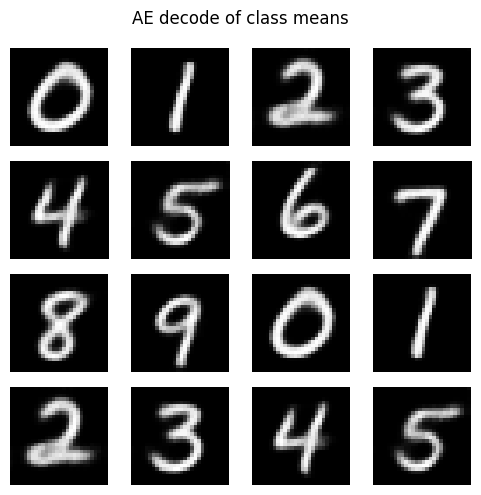

[Stage B] Training conditional QGAN (quantum G, conv D on pixels)...


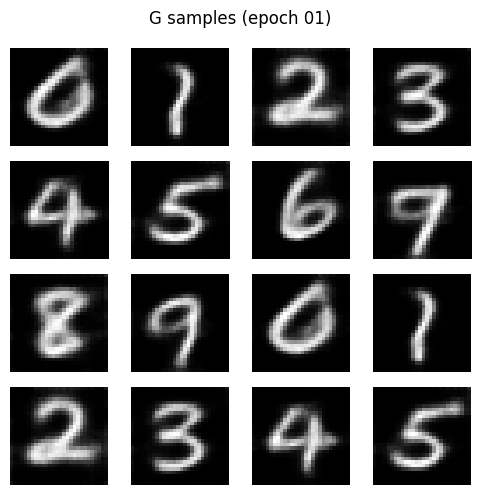

Epoch 01 | D: -136.7807 | G: 16.5191 | noise=0.030


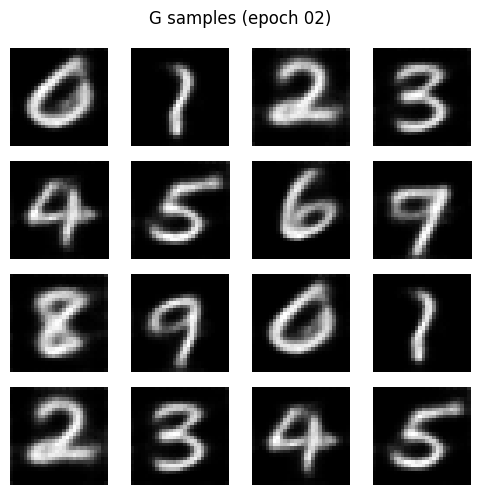

Epoch 02 | D: -408.0763 | G: 64.5993 | noise=0.028


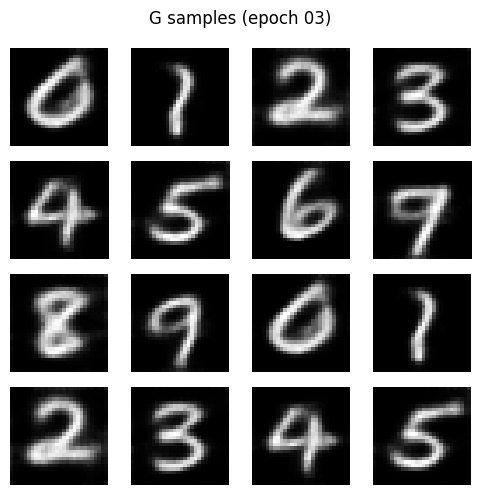

Epoch 03 | D: -503.5814 | G: 22.8428 | noise=0.027


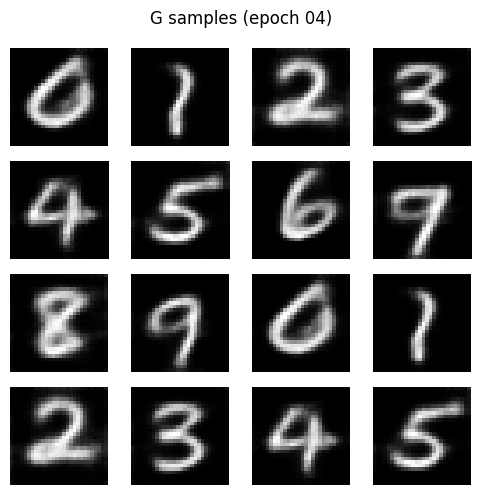

Epoch 04 | D: -751.5975 | G: -30.1837 | noise=0.026


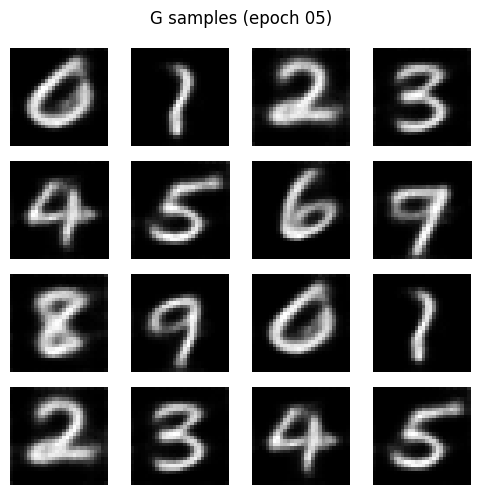

Epoch 05 | D: -649.9186 | G: -50.2323 | noise=0.024


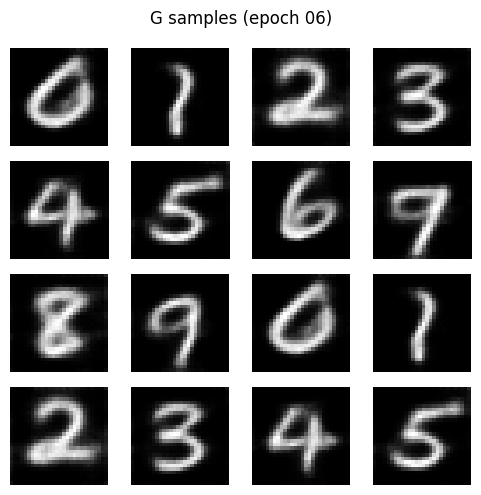

Epoch 06 | D: -938.7478 | G: -161.2252 | noise=0.023


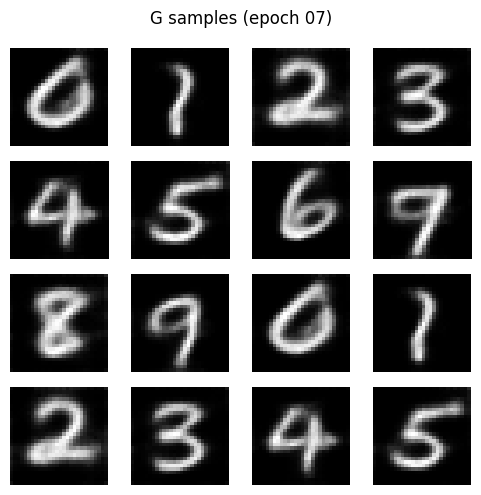

Epoch 07 | D: -930.4454 | G: -612.4149 | noise=0.022


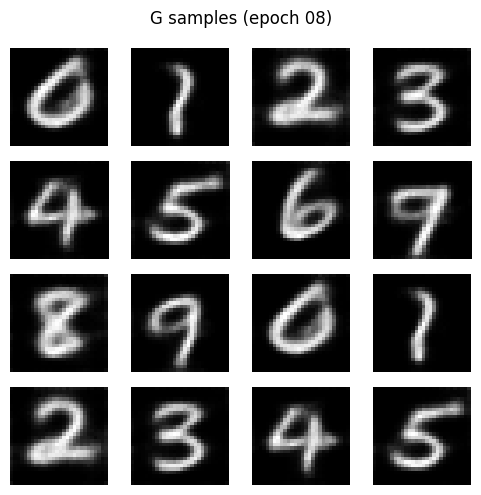

Epoch 08 | D: -1305.9500 | G: -689.9056 | noise=0.021


KeyboardInterrupt: 

In [ ]:

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")

BATCH_AE   = 256
BATCH_GAN  = 64
TOTAL_SAMPLES = 2000          # balanced subset for GAN stage
EPOCHS_AE  = 5                # AE pretrain (increase for better fidelity)
EPOCHS_GAN = 12

CODE_DIM = 12                 # = 2*KQ
KQ = CODE_DIM // 2            # 6 qubits
assert 2*KQ == CODE_DIM

Z_DIM = 64
EMB_DIM = 32
N_GEN_LAYERS = 3
DELTA_SCALE  = 0.35           # size of quantum residual around class mean

LR_D, LR_G  = 3e-4, 1e-4
BETAS       = (0.0, 0.9)
CRITIC_ITERS= 5
LAMBDA_GP   = 10.0
NOISE_STD0  = 0.03
GP_EVERY    = 1

SAVE_DIR="./mnist_cqgan_autoenc_ckpts"; os.makedirs(SAVE_DIR, exist_ok=True)

tfm = transforms.ToTensor()
mnist_full = torchvision.datasets.MNIST(root="./dataset", train=True, transform=tfm, download=True)
mnist_loader_ae = DataLoader(mnist_full, batch_size=BATCH_AE, shuffle=True, drop_last=True)

def balanced_subset(ds, n_total=TOTAL_SAMPLES):
    per = n_total//10
    xs, ys, cnt = [], [], [0]*10
    for x,y in ds:
        y=int(y)
        if cnt[y]<per:
            xs.append(x); ys.append(y); cnt[y]+=1
        if sum(cnt)==per*10: break
    X = torch.stack(xs,0)       # [N,1,28,28]
    Y = torch.tensor(ys)        # [N]
    return X, Y
X_bal, Y_bal = balanced_subset(mnist_full)
mnist_bal_loader = DataLoader(TensorDataset(X_bal, Y_bal), batch_size=BATCH_GAN, shuffle=True, drop_last=True)

class ConvAE(nn.Module):
    def __init__(self, code_dim=12):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,32,3,2,1), nn.ReLU(True),      # 14x14
            nn.Conv2d(32,64,3,2,1), nn.ReLU(True),     # 7x7
        )
        self.enc_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128), nn.ReLU(True),
            nn.Linear(128, code_dim)
        )
        self.dec_fc = nn.Sequential(
            nn.Linear(code_dim,128), nn.ReLU(True),
            nn.Linear(128,64*7*7), nn.ReLU(True),
        )
        self.dec = nn.Sequential(
            nn.Unflatten(1,(64,7,7)),
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(True),   # 14x14
            nn.ConvTranspose2d(32,1,4,2,1), nn.Sigmoid()      # 28x28
        )
    def encode(self,x): return self.enc_fc(self.enc(x))
    def decode(self,z): return self.dec(self.dec_fc(z))
    def forward(self,x):
        z = self.encode(x); xr = self.decode(z); return xr, z

AE = ConvAE(CODE_DIM)
optAE = optim.Adam(AE.parameters(), lr=1e-3)
lossAE = nn.MSELoss()

print("[Stage A] Training autoencoder...")
for ep in range(1, EPOCHS_AE+1):
    AE.train(); runL=0.0
    for xb, _ in mnist_loader_ae:
        xr, _ = AE(xb)
        l = lossAE(xr, xb)
        optAE.zero_grad(); l.backward(); optAE.step()
        runL += l.item()
    print(f"AE Epoch {ep:02d} | recon MSE: {runL/len(mnist_loader_ae):.4f}")

AE.eval(); class_means = []
with torch.no_grad():
    all_codes = [[] for _ in range(10)]
    for xb, yb in DataLoader(mnist_full, batch_size=512):
        z = AE.encode(xb)
        for i,yy in enumerate(yb.tolist()):
            all_codes[yy].append(z[i])
    for c in range(10):
        class_means.append(torch.mean(torch.stack(all_codes[c],0), dim=0))
class_means = torch.stack(class_means,0)  # [10, CODE_DIM]

@torch.no_grad()
def show_codes(title, codes, path=None):
    imgs = AE.decode(codes).numpy()
    r=c=int(len(imgs)**0.5)
    plt.figure(figsize=(5,5))
    for i in range(len(imgs)):
        plt.subplot(r,c,i+1); plt.imshow(imgs[i,0], cmap="gray"); plt.axis("off")
    plt.suptitle(title); plt.tight_layout()
    if path: plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

with torch.no_grad():
    samples = torch.stack([class_means[i] for i in range(10)] + [class_means[i] for i in range(6)],0)
    show_codes("AE decode of class means", samples)

def try_lightning_device(n_wires):
    try:
        return qml.device("lightning.qubit", wires=n_wires)
    except Exception:
        return qml.device("default.qubit", wires=n_wires)

def make_gen_qnode(kq, n_layers):
    dev = try_lightning_device(kq)

    @qml.qnode(dev, interface="torch")
    def qnode(inputs, W1, E1):                 # was: def qnode(u, W1, E1)
        ang = math.pi * inputs  
        # u in [0,1]^kq → fixed encoder
        for L in range(n_layers):
            for i in range(kq): qml.RY(ang[i], wires=i)
            for i in range(kq):
                qml.RX(W1[L,i,0], wires=i); qml.RY(W1[L,i,1], wires=i); qml.RZ(W1[L,i,2], wires=i)
            for i in range(kq): qml.IsingXX(E1[L,i], wires=[i,(i+1)%kq])
        outs = [qml.expval(qml.PauliZ(i)) for i in range(kq)]
        outs += [qml.expval(qml.PauliX(i)) for i in range(kq)]
        return outs  # [-1,1]^(2*kq)
    wsh = {"W1": (n_layers, kq, 3), "E1": (n_layers, kq)}
    return qnode, wsh

class QGenerator(nn.Module):
    # G(z,y) -> code_hat = mu_y + DELTA_SCALE * qnode(pre(z,y))
    def __init__(self, kq, n_layers, z_dim=64, emb_dim=32, class_means=None):
        super().__init__()
        qnode, wsh = make_gen_qnode(kq, n_layers)
        self.layer = TorchLayer(qnode, wsh)
        self.embed = nn.Embedding(10, emb_dim)
        self.pre = nn.Sequential(
            nn.Linear(z_dim+emb_dim, 128), nn.ReLU(True),
            nn.Linear(128, kq), nn.Sigmoid()
        )
        self.register_buffer("class_means", class_means.clone().detach())
    def forward(self, z, y):
        u = self.pre(torch.cat([z, self.embed(y)], dim=1))     # [B,kq] in [0,1]
        raw = torch.clamp(_apply_layer_batched(self.layer, u), -1, 1) # [B,CODE_DIM]
        delta = DELTA_SCALE * raw
        mu = self.class_means[y]
        code_hat = torch.clamp(mu + delta, -3.0, 3.0)          # keep codes bounded
        return code_hat

def sn(module): return nn.utils.spectral_norm(module)

class MinibatchStd1D(nn.Module):
    def forward(self, x):  # x: [B, F]
        if x.size(0)<=1: s = torch.zeros((x.size(0),1), device=x.device)
        else: s = x.std(dim=0, unbiased=False).mean().expand(x.size(0),1)
        return torch.cat([x,s],1)

class ProjConvCritic(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.f = nn.Sequential(
            sn(nn.Conv2d(1,32,3,2,1)), nn.LeakyReLU(0.2,True),   # 14x14
            sn(nn.Conv2d(32,64,3,2,1)), nn.LeakyReLU(0.2,True),  # 7x7
            nn.Flatten(),
            nn.Linear(64*7*7,128), nn.LeakyReLU(0.2,True)
        )
        self.mbstd = MinibatchStd1D()
        self.head = nn.Linear(128+1,1)
        self.embed = nn.Embedding(num_classes, 128)
    def forward(self, x, y):
        h = self.f(x)                # [B,128]
        hmb = self.mbstd(h)          # [B,129]
        s = self.head(hmb).squeeze(1)
        proj = (h * self.embed(y)).sum(1)
        return (s + proj).unsqueeze(1)

G  = QGenerator(KQ, N_GEN_LAYERS, Z_DIM, EMB_DIM, class_means)
D  = ProjConvCritic()

optG = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
optD = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)

def sample_z(b): return torch.randn((b, Z_DIM))
def sample_y(b): return torch.randint(0,10,(b,),dtype=torch.long)

@torch.no_grad()
def grid_show(imgs, title, path=None):
    n = len(imgs); r=c=int(n**0.5)
    plt.figure(figsize=(5,5))
    for i in range(n):
        plt.subplot(r,c,i+1); plt.imshow(imgs[i,0], cmap="gray"); plt.axis("off")
    plt.suptitle(title); plt.tight_layout()
    if path: plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

print("[Stage B] Training conditional QGAN (quantum G, conv D on pixels)...")
step=0
for ep in range(1, EPOCHS_GAN+1):
    NOISE_STD = max(0.01, NOISE_STD0 * (0.95 ** (ep-1)))
    for xb, yb in mnist_bal_loader:
        # ---- D updates ----
        for _ in range(CRITIC_ITERS):
            zf, yf = sample_z(xb.size(0)), sample_y(xb.size(0))
            with torch.no_grad():
                codes = G(zf, yf)
                x_fake = AE.decode(codes)                     # [B,1,28,28]
            x_real = xb
            # instance noise
            x_real = (x_real + NOISE_STD*torch.randn_like(x_real)).clamp(0,1)
            x_fake = (x_fake + NOISE_STD*torch.randn_like(x_fake)).clamp(0,1)

            optD.zero_grad()
            d_real = D(x_real, yb).mean()
            d_fake = D(x_fake, yf).mean()
            wdist = d_real - d_fake

            # GP (keep labels fixed to yf)
            if step % GP_EVERY == 0:
                eps = torch.rand((xb.size(0),1,1,1))
                xhat = (eps*x_real + (1-eps)*x_fake).requires_grad_(True)
                d_hat = D(xhat, yf).mean()
                grad = torch.autograd.grad(d_hat, xhat, create_graph=True, retain_graph=True, only_inputs=True)[0]
                gp = ((grad.view(grad.size(0), -1).norm(2, dim=1) - 1) ** 2).mean() * LAMBDA_GP
            else:
                gp = torch.tensor(0.0)

            d_loss = -(wdist) + gp
            d_loss.backward(); optD.step(); step += 1

        # ---- G update ----
        yg, zg = sample_y(xb.size(0)), sample_z(xb.size(0))
        codes = G(zg, yg)
        x_fake = AE.decode(codes)
        x_fake = (x_fake + NOISE_STD*torch.randn_like(x_fake)).clamp(0,1)
        optG.zero_grad()
        g_loss = -D(x_fake, yg).mean()
        g_loss.backward(); optG.step()

    # epoch end: visualize conditional grid (0..9)
    with torch.no_grad():
        z = sample_z(16); y = torch.tensor([0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5])
        imgs = AE.decode(G(z,y))
        grid_show(imgs, f"G samples (epoch {ep:02d})")

    print(f"Epoch {ep:02d} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f} | noise={NOISE_STD:.3f}")
